# Financial Time Series Basics
### Returns · Volatility · Correlation · Covariance · Risk Metrics

A practical, hands-on introduction to the core statistical building blocks used in quantitative finance.  
Every section includes a conceptual explanation, mathematical definition, real-world context, and live code with visualizations — all on realistic mock data.

### Beginner Explanation

This notebook teaches the basic statistics behind financial data step by step. If you are new to quant finance, focus on one question in each section: **what does this statistic measure, and why does an investor care?**

A simple way to think about the notebook is:

- returns tell us how prices change
- volatility tells us how uncertain those changes are
- correlation and covariance tell us how assets move together
- risk metrics tell us how bad losses can get
- portfolio construction shows how all the pieces fit together

## 1. Imports & Mock Price Data Generation

We simulate 5 years of daily prices for **four assets**:
- **TECH** — high-growth, high-volatility tech stock
- **BANK** — moderate-growth cyclical financial stock  
- **BOND** — low-volatility fixed-income-like instrument
- **MARKET** — broad market index (S&P 500 proxy)

All prices are generated using **Geometric Brownian Motion (GBM)**:
$$S_t = S_0 \cdot \exp\!\left[\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t\right]$$

where $\mu$ is the drift (annualized expected return) and $\sigma$ is volatility (annualized). This is the same model underlying the Black-Scholes option pricing formula.

### Why GBM?
- Prices are always positive (log-normal)
- Daily returns are approximately normally distributed
- It matches the stylized facts of real equity prices well enough for educational purposes

### Beginner Explanation

This section creates fake but realistic-looking asset prices so the rest of the notebook has something to analyze. You can think of it as building a practice market in a controlled environment.

The key idea is that each asset has:

- an average growth tendency called **drift**
- a randomness level called **volatility**
- a starting price

So before doing any statistics, we first need a price history.

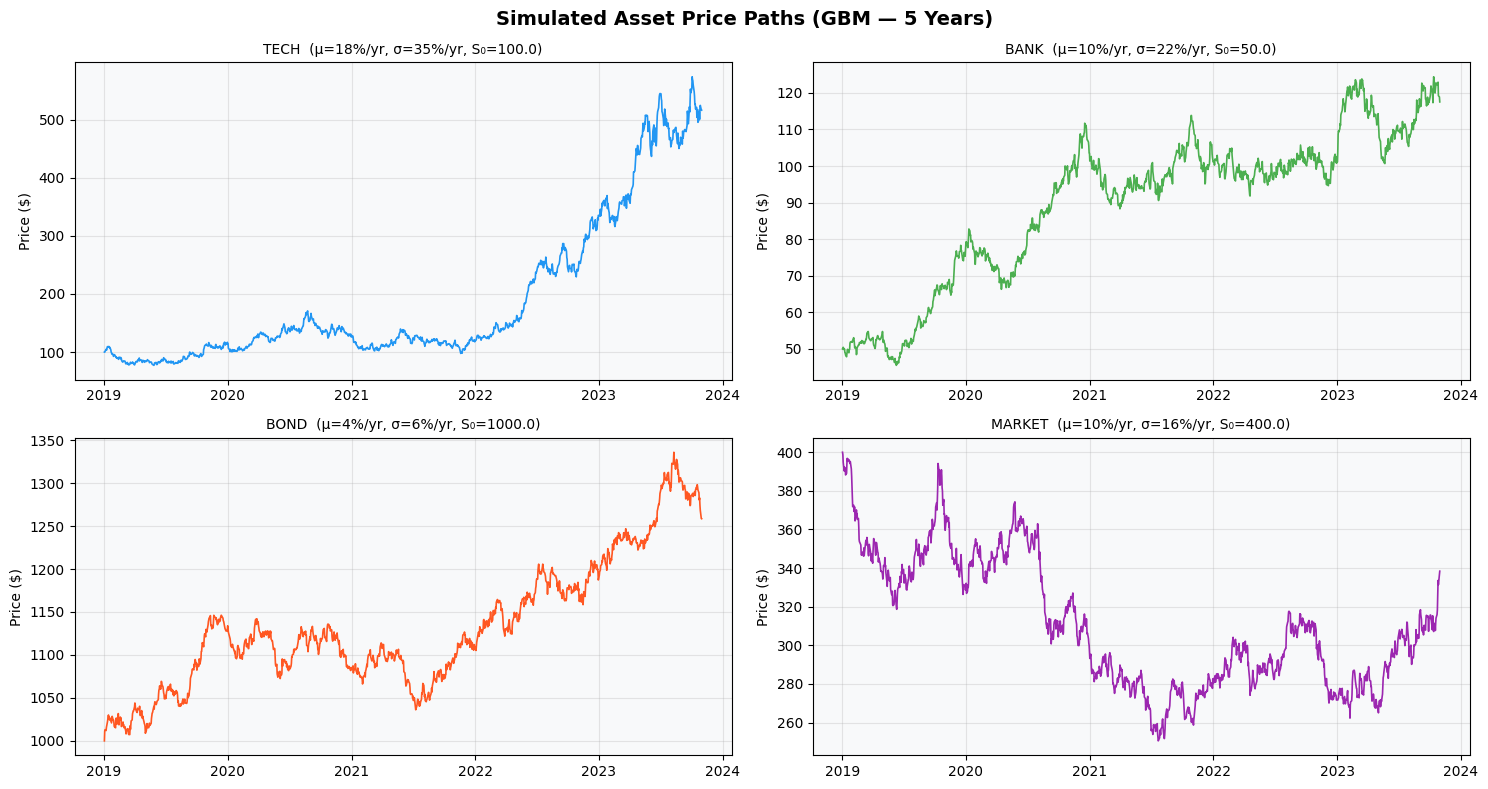

Dataset: 1260 trading days | 4 assets
Date range: 2019-01-02 → 2023-10-31

Final prices:
TECH       516.177722
BANK       117.519194
BOND      1258.544807
MARKET     338.402372


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

# Global plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        10,
})
np.random.seed(42)

# ── Simulation parameters ──────────────────────────────────────────────────────
n_days      = 1260          # 5 years of trading days
dt          = 1 / 252       # one day as a fraction of a year

# Asset parameters: (annualized_mu, annualized_sigma, starting_price)
assets = {
    'TECH':   (0.18, 0.35, 100.0),   # high drift, high vol
    'BANK':   (0.10, 0.22, 50.0),    # moderate drift, moderate vol
    'BOND':   (0.04, 0.06, 1000.0),  # low drift, low vol
    'MARKET': (0.10, 0.16, 400.0),   # index-like
}

# ── Generate GBM price paths ───────────────────────────────────────────────────
dates = pd.bdate_range('2019-01-02', periods=n_days)
prices = {}
for name, (mu, sigma, S0) in assets.items():
    Z = np.random.standard_normal(n_days)
    daily_returns = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    daily_returns[0] = 1.0                        # first day: no change
    prices[name] = S0 * daily_returns.cumprod()

df_prices = pd.DataFrame(prices, index=dates)

# ── Plot price paths ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle('Simulated Asset Price Paths (GBM — 5 Years)', fontsize=14, fontweight='bold')
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']

for ax, (name, color) in zip(axes.flat, zip(assets.keys(), colors)):
    mu, sigma, S0 = assets[name]
    ax.plot(df_prices.index, df_prices[name], color=color, lw=1.2)
    ax.set_title(f'{name}  (μ={mu:.0%}/yr, σ={sigma:.0%}/yr, S₀={S0})', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

print(f"Dataset: {n_days} trading days | {len(assets)} assets")
print(f"Date range: {dates[0].date()} → {dates[-1].date()}")
print(f"\nFinal prices:")
print(df_prices.iloc[-1].to_string())

## 2. Simple Returns vs. Log Returns

Returns are the *fundamental unit of analysis* in finance. Prices are non-stationary (they trend), but returns approximate stationarity. There are two conventions:

### Simple (Arithmetic) Return
$$R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$

**When to use**: Portfolio aggregation across assets. Portfolio return = weighted sum of asset simple returns:
$$R_p = \sum_i w_i R_i$$

### Log (Continuously Compounded) Return
$$r_t = \ln\!\left(\frac{P_t}{P_{t-1}}\right) = \ln(P_t) - \ln(P_{t-1})$$

**When to use**: Aggregation *over time*. Multi-period log return = sum of single-period log returns:
$$r_{0 \to T} = \sum_{t=1}^{T} r_t$$

### Key Differences
| Property | Simple Return | Log Return |
|-----------|--------------|-----------|
| Time aggregation | Multiplicative | Additive ✅ |
| Asset aggregation | Additive ✅ | Approximate |
| Distribution | Right-skewed | More symmetric |
| Range | $(-1, +\infty)$ | $(-\infty, +\infty)$ |
| Small values | $R \approx r$ | $r \approx R$ |

> **Rule of thumb**: For returns under ~2% per period, $R_t \approx r_t$. For long horizons or high-vol assets, they diverge significantly.

### Beginner Explanation

A **return** tells you the percentage change in price from one period to the next. That is why quants usually work with returns instead of raw prices: prices trend over time, but returns are easier to compare and model.

A useful shortcut is:

- **simple return** is easier for portfolio weights and intuition
- **log return** is easier for adding over time and for many statistical models

For small daily moves, both numbers are almost the same.

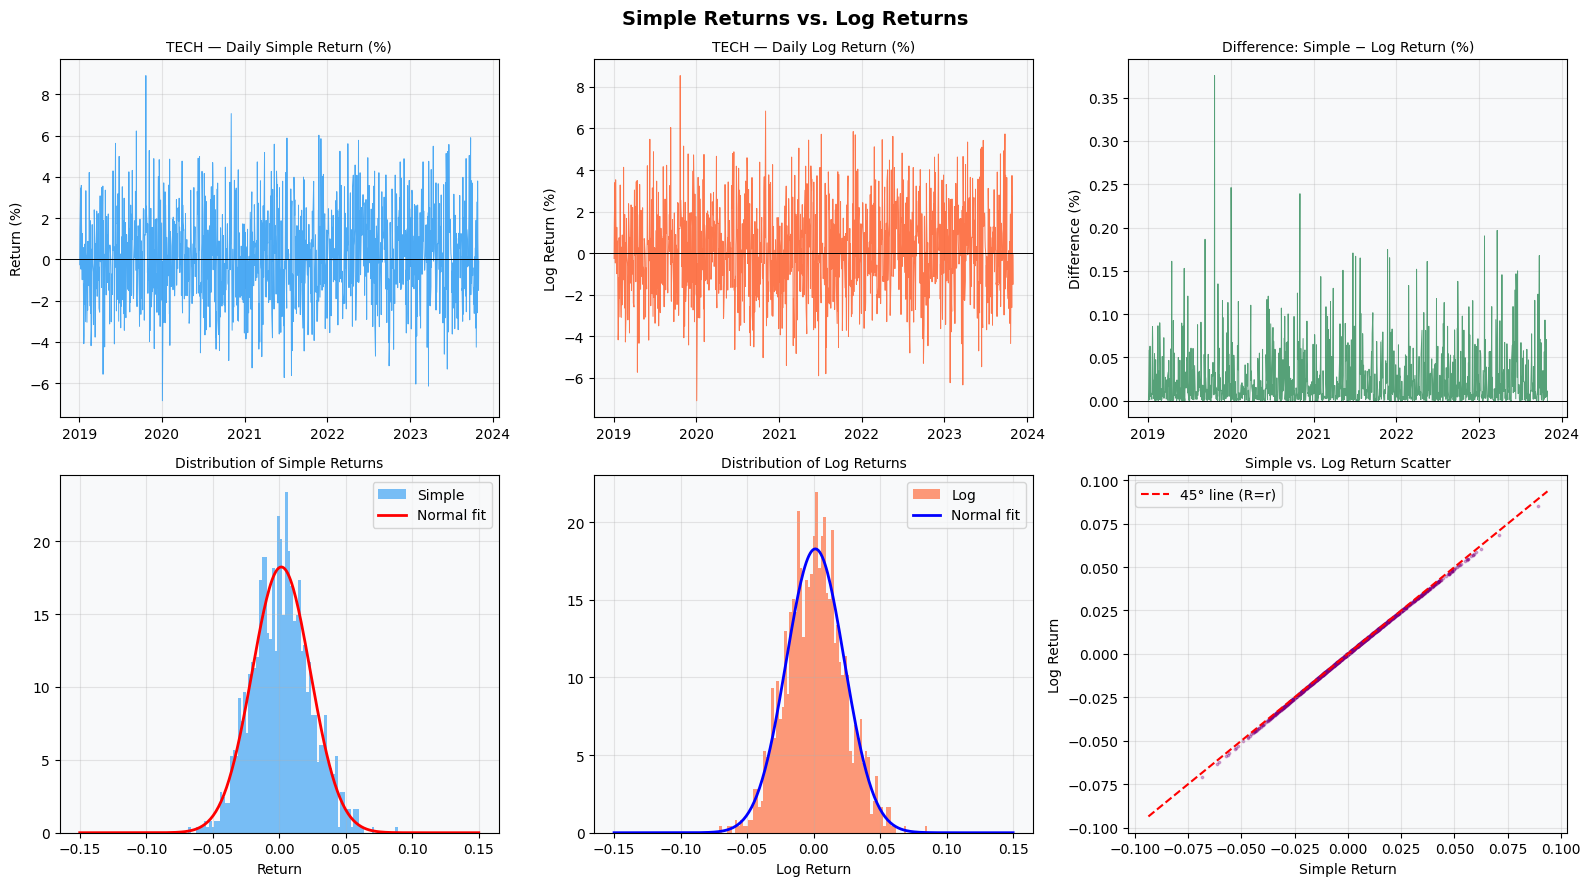

=== Return Summary Statistics (TECH, daily) ===
       Mean (daily) Mean (annual) Std (daily) Std (annual) Skewness Excess Kurtosis      Min     Max
Simple     0.001543        0.3888    0.021879       0.3473   0.1462          0.0444  -0.0685  0.0892
Log        0.001304        0.3285    0.021823       0.3464   0.0803          0.0187  -0.0710  0.0854


In [2]:
# ── Compute simple and log returns ────────────────────────────────────────────
simple_returns = df_prices.pct_change().dropna()         # R_t = (P_t/P_{t-1}) - 1
log_returns    = np.log(df_prices / df_prices.shift(1)).dropna()  # r_t = ln(P_t/P_{t-1})

# ── Plot: Side-by-side return distributions for TECH ──────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Simple Returns vs. Log Returns', fontsize=14, fontweight='bold')

asset = 'TECH'
sr = simple_returns[asset]
lr = log_returns[asset]

# Row 1: Time series of returns
axes[0, 0].plot(sr.index, sr * 100, color='#2196F3', lw=0.7, alpha=0.8)
axes[0, 0].axhline(0, color='black', lw=0.7)
axes[0, 0].set_title(f'{asset} — Daily Simple Return (%)', fontsize=10)
axes[0, 0].set_ylabel('Return (%)')
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[0, 1].plot(lr.index, lr * 100, color='#FF5722', lw=0.7, alpha=0.8)
axes[0, 1].axhline(0, color='black', lw=0.7)
axes[0, 1].set_title(f'{asset} — Daily Log Return (%)', fontsize=10)
axes[0, 1].set_ylabel('Log Return (%)')
axes[0, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Difference between simple and log returns
diff = (sr - lr) * 100
axes[0, 2].plot(diff.index, diff, color='seagreen', lw=0.7, alpha=0.8)
axes[0, 2].axhline(0, color='black', lw=0.7)
axes[0, 2].set_title('Difference: Simple − Log Return (%)', fontsize=10)
axes[0, 2].set_ylabel('Difference (%)')
axes[0, 2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Row 2: Histograms
x = np.linspace(-0.15, 0.15, 300)
axes[1, 0].hist(sr, bins=80, density=True, color='#2196F3', alpha=0.6, label='Simple')
axes[1, 0].plot(x, stats.norm.pdf(x, sr.mean(), sr.std()), 'r-', lw=2, label='Normal fit')
axes[1, 0].set_title('Distribution of Simple Returns', fontsize=10)
axes[1, 0].set_xlabel('Return')
axes[1, 0].legend()

axes[1, 1].hist(lr, bins=80, density=True, color='#FF5722', alpha=0.6, label='Log')
axes[1, 1].plot(x, stats.norm.pdf(x, lr.mean(), lr.std()), 'b-', lw=2, label='Normal fit')
axes[1, 1].set_title('Distribution of Log Returns', fontsize=10)
axes[1, 1].set_xlabel('Log Return')
axes[1, 1].legend()

# Scatter: simple vs log (should be nearly linear for small values)
axes[1, 2].scatter(sr, lr, s=3, alpha=0.3, color='purple')
lim = max(abs(sr).max(), abs(lr).max()) * 1.05
axes[1, 2].plot([-lim, lim], [-lim, lim], 'r--', lw=1.5, label='45° line (R=r)')
axes[1, 2].set_xlabel('Simple Return')
axes[1, 2].set_ylabel('Log Return')
axes[1, 2].set_title('Simple vs. Log Return Scatter', fontsize=10)
axes[1, 2].legend()

plt.tight_layout()
plt.show()

# Summary statistics table
print("=== Return Summary Statistics (TECH, daily) ===")
stats_dict = {}
for name, r in [('Simple', sr), ('Log', lr)]:
    stats_dict[name] = {
        'Mean (daily)':   f"{r.mean():.6f}",
        'Mean (annual)':  f"{r.mean()*252:.4f}",
        'Std (daily)':    f"{r.std():.6f}",
        'Std (annual)':   f"{r.std()*np.sqrt(252):.4f}",
        'Skewness':       f"{r.skew():.4f}",
        'Excess Kurtosis':f"{r.kurt():.4f}",
        'Min':            f"{r.min():.4f}",
        'Max':            f"{r.max():.4f}",
    }
pd.set_option('display.max_columns', None)
print(pd.DataFrame(stats_dict).T.to_string())

## 3. Compounding & Cumulative Returns

**Why cumulative returns matter**: A daily return series needs to be *compounded* to see how $1 invested grows over time. This is what investors actually experience.

### Formulas

**Cumulative simple return** (how much $1 grew):
$$\text{Cumulative Return}_T = \prod_{t=1}^{T}(1 + R_t) - 1$$

**Cumulative log return** (sum of log returns, then exponentiate):
$$\text{Cumulative Return}_T = e^{\sum_{t=1}^{T} r_t} - 1$$

Both give identical results — the two methods are equivalent.

### Annualization
To compare performance across assets and time periods, returns are **annualized**:
$$\text{CAGR} = \left(\frac{P_T}{P_0}\right)^{252/T} - 1$$

where $T$ is the number of trading days. This is the **Compound Annual Growth Rate (CAGR)** — the single constant return that would produce the same terminal value.

### Beginner Explanation

A series of daily returns by itself can feel abstract. Compounding translates those daily changes into the growth of an actual investment.

If you invest $1 and keep reinvesting gains and losses, cumulative return shows what that $1 becomes over time. CAGR then turns that full journey into a single average annual growth rate, which is easier to compare across assets.

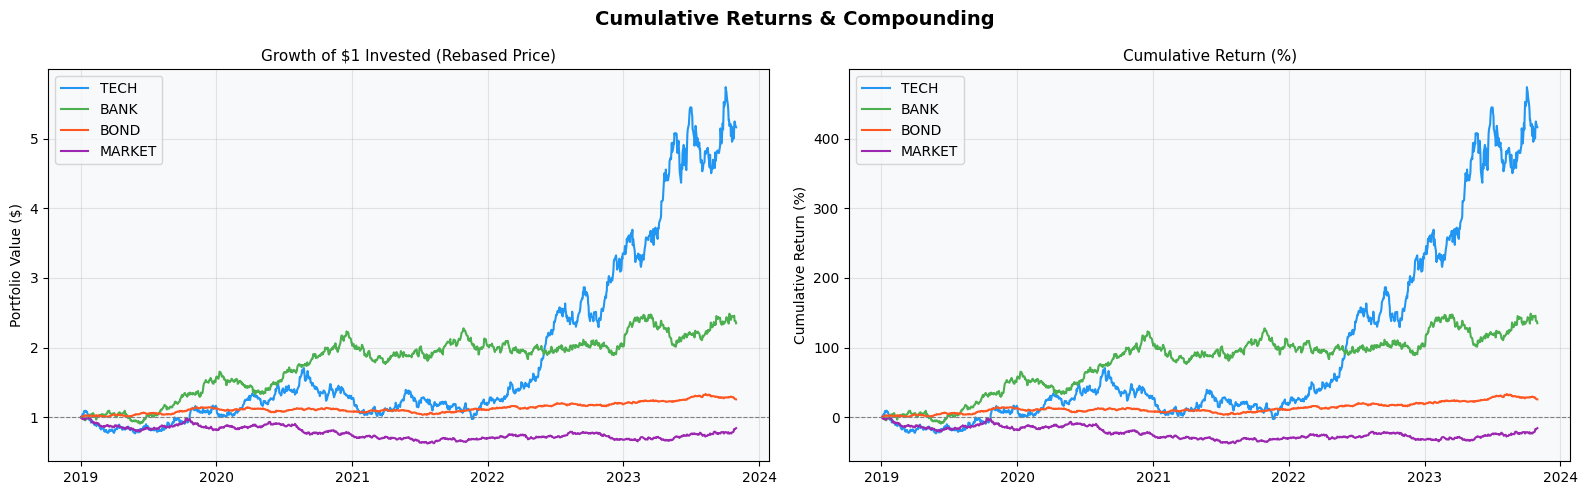

=== Performance Summary (5-Year) ===
                     TECH    BANK     BOND  MARKET
Total Return (%)   416.18  135.04    25.85  -15.40
CAGR (%)            38.89   18.66     4.71   -3.29
True μ_annual (%)   18.00   10.00     4.00   10.00
Final Price ($)    516.18  117.52  1258.54  338.40


In [3]:
# ── Cumulative returns ─────────────────────────────────────────────────────────
# Method 1: compound simple returns
cum_simple = (1 + simple_returns).cumprod() - 1

# Method 2: cumulate log returns
cum_log = np.exp(log_returns.cumsum()) - 1

# Normalized price (rebased to 1.0 at start for comparison)
rebased = df_prices / df_prices.iloc[0]

# ── CAGR ──────────────────────────────────────────────────────────────────────
T = len(simple_returns)
cagr = (df_prices.iloc[-1] / df_prices.iloc[0]) ** (252 / T) - 1

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Cumulative Returns & Compounding', fontsize=14, fontweight='bold')

colors_map = {'TECH': '#2196F3', 'BANK': '#4CAF50', 'BOND': '#FF5722', 'MARKET': '#9C27B0'}

# Left: rebased prices (growth of $1)
for col, color in colors_map.items():
    axes[0].plot(rebased.index, rebased[col], label=col, color=color, lw=1.5)
axes[0].axhline(1, color='gray', lw=0.8, linestyle='--')
axes[0].set_title('Growth of $1 Invested (Rebased Price)', fontsize=11)
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Right: cumulative returns %
for col, color in colors_map.items():
    axes[1].plot(cum_simple.index, cum_simple[col] * 100, label=col, color=color, lw=1.5)
axes[1].axhline(0, color='gray', lw=0.8, linestyle='--')
axes[1].set_title('Cumulative Return (%)', fontsize=11)
axes[1].set_ylabel('Cumulative Return (%)')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

# Summary table
print("=== Performance Summary (5-Year) ===")
summary = pd.DataFrame({
    'Total Return (%)':    (cum_simple.iloc[-1] * 100).round(2),
    'CAGR (%)':            (cagr * 100).round(2),
    'True μ_annual (%)':   {name: assets[name][0]*100 for name in assets},
    'Final Price ($)':     df_prices.iloc[-1].round(2),
}).T
print(summary.to_string())

## 4. Variance, Standard Deviation & Z-Score — Measuring Risk

**Risk in finance = uncertainty of returns**. If you knew exactly what a stock would return, there'd be no risk. Variance quantifies the *spread* of the return distribution around its mean.

### Variance
$$\sigma^2 = \frac{1}{T-1} \sum_{t=1}^{T} (r_t - \bar{r})^2$$

The average squared deviation of returns from their mean. Squaring makes all deviations positive and penalizes large deviations heavily.

### Standard Deviation
$$\sigma = \sqrt{\sigma^2}$$

Because variance is in units of *return²*, we take the square root to get standard deviation — the same units as returns. **Daily volatility** $\sigma_{daily}$ is the standard deviation of daily log returns.

### Annualization (the $\sqrt{T}$ rule)
Under the assumption of i.i.d. returns (each day is independent):
$$\sigma_{annual} = \sigma_{daily} \times \sqrt{252}$$

This comes from the fact that variance *scales linearly* with time, so standard deviation scales with $\sqrt{T}$.

### Z-Score — Standardizing Returns
The Z-score expresses a return in units of **standard deviations from the mean**:
$$z_t = \frac{r_t - \bar{r}}{\sigma}$$

A Z-score of +2 means the return was 2 standard deviations above average — an unusual but not extreme move. A Z-score of ±3 or beyond is a statistical outlier (probability < 0.3% under normality).

**Why Z-scores matter in quant finance:**
- **Outlier / crash detection**: Flag days where $|z_t| > 3$ as stress events (2008 GFC had many $z < -5$ days, far beyond what a normal distribution predicts)
- **Cross-asset signal comparison**: A momentum signal on TECH (high vol) and BOND (low vol) can't be compared in raw return units — normalize both to Z-scores first
- **Mean-reversion strategies**: If a stock's Z-score is $-2.5$ (2.5σ below its rolling mean), a mean-reversion trader bets it will revert back — this is the statistical basis of pairs trading
- **Risk limits**: Desk-level risk limits are often expressed as "flag if 5-day return Z-score exceeds ±3"

| Z-score range | Probability (normal) | Interpretation |
|---|---|---|
| $\|z\| < 1$ | 68.3% of days | Normal daily fluctuation |
| $\|z\| < 2$ | 95.4% of days | Typical range |
| $\|z\| < 3$ | 99.7% of days | Unusual move |
| $\|z\| > 3$ | 0.3% of days | Outlier / stress event |
| $\|z\| > 5$ | 0.00006% | "Six-sigma" — impossible under normality, common in crises |

### Why It Matters
| Context | How Volatility / Z-score Is Used |
|---------|----------------------------------|
| Options pricing | Core input to Black-Scholes: $C = f(S, K, T, r, \sigma)$ |
| Value at Risk (VaR) | $\text{VaR}_{95\%} = -(\mu - 1.645\sigma)$ — 1.645 is the Z-score cutoff |
| Portfolio construction | Minimize $\sigma_p^2 = w^\top \Sigma w$ (Markowitz) |
| Sharpe ratio | Reward per unit of risk = $(\mu - r_f)/\sigma$ |
| Signal normalization | Z-score raw alpha signals before combining in multi-factor models |

### Beginner Explanation

Variance and standard deviation answer a simple question: **how spread out are the returns?**

If returns are tightly grouped near the average, risk is lower. If they are widely spread, risk is higher. A Z-score simply tells you how unusual one observation is compared with the usual range.

So you can think of this section as moving from:

- average move
to
- typical spread around that average
to
- how extreme a given day really was

Manual variance (TECH): 0.00047626
Pandas  variance (TECH): 0.00047626  ✓

=== Z-Score Statistics (TECH) ===
Mean of Z-scores (should ≈ 0):  0.0000
Std  of Z-scores (should ≈ 1):  1.0000
Extreme days |z| > 3:  3  (0.2% — normal theory predicts 0.3%)
Min Z-score: -3.31σ  |  Max Z-score: 3.85σ


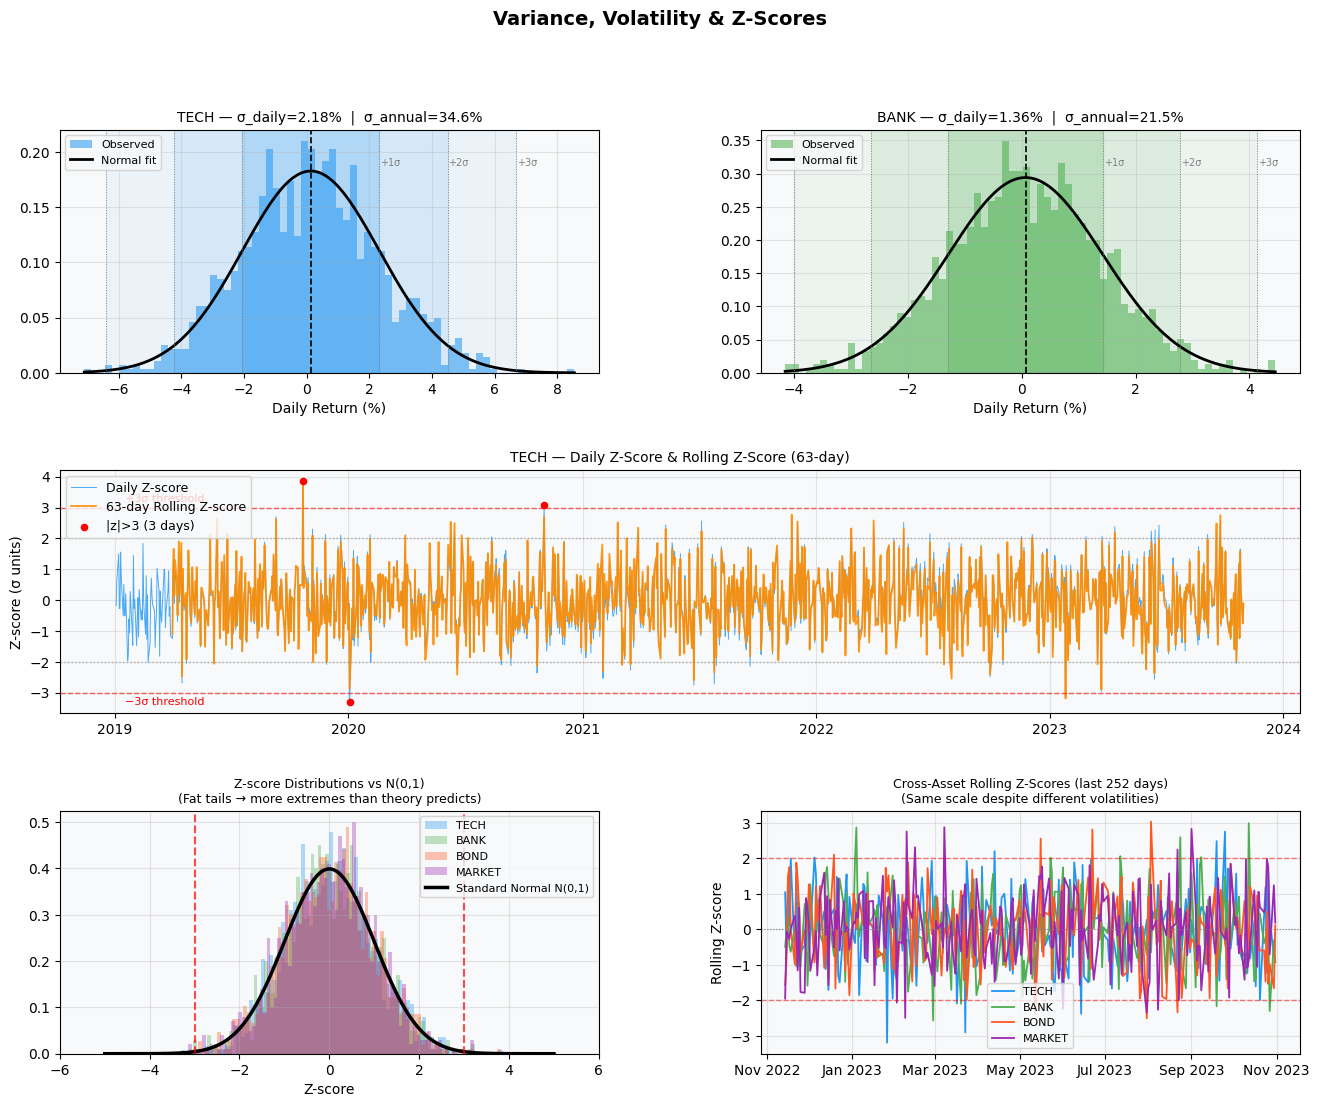


=== Volatility & Z-Score Summary ===
       Daily Std Dev (%) Annual Sigma (%) True σ_annual (%)  |z|>3 days |z|>3 % (actual) |z|>3 % (theory)
TECH              2.1823            34.64             35.00           3            0.24%            0.27%
BANK              1.3564            21.53             22.00           6            0.48%            0.27%
BOND              0.3877             6.16              6.00           2            0.16%            0.27%
MARKET            1.0036            15.93             16.00           5            0.40%            0.27%


In [4]:
# ── Variance & Volatility ──────────────────────────────────────────────────────
r = log_returns   # use log returns for vol calculations

daily_mean = r.mean()
daily_var  = r.var(ddof=1)    # unbiased: divide by T-1
daily_std  = r.std(ddof=1)

annual_var = daily_var * 252
annual_std = daily_std * np.sqrt(252)   # annualized volatility

# Manual calculation check (for TECH)
tech_r = r['TECH']
manual_var = ((tech_r - tech_r.mean())**2).sum() / (len(tech_r) - 1)
print(f"Manual variance (TECH): {manual_var:.8f}")
print(f"Pandas  variance (TECH): {tech_r.var(ddof=1):.8f}  ✓")

# ── Z-scores ───────────────────────────────────────────────────────────────────
# z_t = (r_t - mean) / std  — standardizes each return into σ units
z_scores = (r - r.mean()) / r.std(ddof=1)

# Rolling Z-score (63-day window) — compares today's return to recent history
z_roll = (r - r.rolling(63).mean()) / r.rolling(63).std(ddof=1)

# Identify extreme days (|z| > 3) for TECH
extreme_days = z_scores['TECH'][z_scores['TECH'].abs() > 3]

print(f"\n=== Z-Score Statistics (TECH) ===")
print(f"Mean of Z-scores (should ≈ 0):  {z_scores['TECH'].mean():.4f}")
print(f"Std  of Z-scores (should ≈ 1):  {z_scores['TECH'].std():.4f}")
print(f"Extreme days |z| > 3:  {len(extreme_days)}  ({len(extreme_days)/len(z_scores)*100:.1f}% — normal theory predicts 0.3%)")
print(f"Min Z-score: {z_scores['TECH'].min():.2f}σ  |  Max Z-score: {z_scores['TECH'].max():.2f}σ")

# ── Plots ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Variance, Volatility & Z-Scores', fontsize=14, fontweight='bold')
gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.3)

# Row 1: Return distributions with ±1σ shading (2 assets)
for i, (name, color) in enumerate(list(colors_map.items())[:2]):
    ax = fig.add_subplot(gs[0, i])
    asset_r = r[name]
    ax.hist(asset_r * 100, bins=70, density=True, color=color, alpha=0.55, label='Observed')
    x_range = np.linspace(asset_r.min() * 100, asset_r.max() * 100, 300)
    ax.plot(x_range, stats.norm.pdf(x_range, asset_r.mean()*100, asset_r.std(ddof=1)*100),
            'k-', lw=2, label='Normal fit')
    mu_pct = asset_r.mean() * 100
    sd_pct = asset_r.std(ddof=1) * 100
    for k, alpha_val in [(1, 0.20), (2, 0.10), (3, 0.06)]:
        ax.axvspan(mu_pct - k*sd_pct, mu_pct + k*sd_pct, alpha=alpha_val, color=color)
    ax.axvline(mu_pct, color='black', lw=1.2, linestyle='--')
    ann_vol = daily_std[name] * np.sqrt(252) * 100
    ax.set_title(f'{name} — σ_daily={sd_pct:.2f}%  |  σ_annual={ann_vol:.1f}%', fontsize=10)
    ax.set_xlabel('Daily Return (%)')
    ax.legend(fontsize=8)
    # Annotate σ bands
    for k in [1, 2, 3]:
        ax.axvline(mu_pct + k*sd_pct, color='gray', lw=0.7, linestyle=':')
        ax.axvline(mu_pct - k*sd_pct, color='gray', lw=0.7, linestyle=':')
        ax.text(mu_pct + k*sd_pct + 0.02, ax.get_ylim()[1]*0.85,
                f'+{k}σ', fontsize=7, color='gray')

# Row 2: Full-sample Z-score time series for TECH
ax2a = fig.add_subplot(gs[1, :])
ax2a.plot(z_scores.index, z_scores['TECH'], color='#2196F3', lw=0.7, alpha=0.8, label='Daily Z-score')
ax2a.plot(z_roll.index,   z_roll['TECH'],   color='darkorange', lw=1.3, alpha=0.9, label='63-day Rolling Z-score')
for thresh, col, ls in [(3, 'red', '--'), (-3, 'red', '--'), (2, 'gray', ':'), (-2, 'gray', ':')]:
    ax2a.axhline(thresh, color=col, lw=1, linestyle=ls, alpha=0.6)
# Mark extreme days
ax2a.scatter(extreme_days.index, extreme_days.values,
             color='red', s=20, zorder=5, label=f'|z|>3 ({len(extreme_days)} days)')
ax2a.set_title('TECH — Daily Z-Score & Rolling Z-Score (63-day)', fontsize=10)
ax2a.set_ylabel('Z-score (σ units)')
ax2a.legend(fontsize=9)
ax2a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2a.text(z_scores.index[10], 3.2, '+3σ threshold', fontsize=8, color='red')
ax2a.text(z_scores.index[10], -3.4, '−3σ threshold', fontsize=8, color='red')

# Row 3: Z-score distribution vs standard normal + cross-asset comparison
ax3a = fig.add_subplot(gs[2, 0])
x_z = np.linspace(-5, 5, 300)
for name, color in colors_map.items():
    ax3a.hist(z_scores[name], bins=80, density=True, alpha=0.35, color=color, label=name)
ax3a.plot(x_z, stats.norm.pdf(x_z, 0, 1), 'k-', lw=2.5, label='Standard Normal N(0,1)')
ax3a.axvline( 3, color='red', lw=1.5, linestyle='--', alpha=0.7)
ax3a.axvline(-3, color='red', lw=1.5, linestyle='--', alpha=0.7)
ax3a.set_xlabel('Z-score')
ax3a.set_title('Z-score Distributions vs N(0,1)\n(Fat tails → more extremes than theory predicts)', fontsize=9)
ax3a.legend(fontsize=8)
ax3a.set_xlim(-6, 6)

# Cross-asset Z-score on a single reference date range (shows normalization benefit)
ax3b = fig.add_subplot(gs[2, 1])
# Rolling 63-day Z-score for all assets — recent 252 days
recent_z = z_roll.iloc[-252:]
for name, color in colors_map.items():
    ax3b.plot(recent_z.index, recent_z[name], label=name, color=color, lw=1.3)
ax3b.axhline( 2, color='red',  lw=1,   linestyle='--', alpha=0.5)
ax3b.axhline(-2, color='red',  lw=1,   linestyle='--', alpha=0.5)
ax3b.axhline( 0, color='gray', lw=0.8, linestyle=':')
ax3b.set_title('Cross-Asset Rolling Z-Scores (last 252 days)\n(Same scale despite different volatilities)', fontsize=9)
ax3b.set_ylabel('Rolling Z-score')
ax3b.legend(fontsize=8)
ax3b.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.show()

# ── Summary table ──────────────────────────────────────────────────────────────
print("\n=== Volatility & Z-Score Summary ===")
extreme_counts = {name: (z_scores[name].abs() > 3).sum() for name in r.columns}
vol_table = pd.DataFrame({
    'Daily Std Dev (%)':  (daily_std * 100).map('{:.4f}'.format),
    'Annual Sigma (%)':   (annual_std * 100).map('{:.2f}'.format),
    'True σ_annual (%)':  {name: f"{assets[name][1]*100:.2f}" for name in assets},
    '|z|>3 days':         extreme_counts,
    '|z|>3 % (actual)':   {n: f"{v/len(r)*100:.2f}%" for n, v in extreme_counts.items()},
    '|z|>3 % (theory)':   {n: '0.27%' for n in r.columns},
})
print(vol_table.to_string())

## 5. Rolling Volatility & Volatility Ratio — How Risk Changes Over Time

A single volatility estimate over the full sample is a useful summary, but it hides the fact that **volatility is not constant**. Markets are calm for long periods and then suddenly turbulent. This phenomenon is called **volatility clustering**: large moves tend to be followed by more large moves.

### Rolling Volatility Formula
$$\sigma_t^{(W)} = \sqrt{\frac{1}{W-1} \sum_{s=t-W+1}^{t} (r_s - \bar{r}_t)^2} \times \sqrt{252}$$

Computed over a sliding window of length $W$ days, then annualized.

### Volatility Ratio (VR)
The **Volatility Ratio** compares short-term volatility to long-term volatility to detect whether the market is entering or leaving a stress regime:

$$\text{VR}_t = \frac{\sigma_t^{(\text{short})}}{\sigma_t^{(\text{long})}}$$

A common implementation: short = 21-day, long = 252-day:
$$\text{VR}_t = \frac{\sigma_t^{(21)}}{\sigma_t^{(252)}}$$

| VR value | Interpretation | Action |
|----------|---------------|--------|
| $\text{VR} \approx 1$ | Current vol matches long-run average | Normal regime |
| $\text{VR} > 1.5$ | Short-term vol spiking above trend | Risk-off: reduce positions |
| $\text{VR} > 2.0$ | Stress regime — vol has doubled | Defensive posture, widen stop-losses |
| $\text{VR} < 0.7$ | Unusually calm — vol compression | Potential vol expansion ahead; option buyers alert |

### Why Volatility Ratio Matters
- **Position sizing (vol targeting)**: Strategies like risk parity scale exposure as $\text{size} \propto 1/\sigma_{\text{short}}$. The VR signals how aggressively to scale back when short-term vol spikes.
- **Options trading**: A rising VR means implied vol is likely to follow. Vol traders use it to time buying straddles (when VR is depressed and a spike is expected) vs. selling premium (when VR is elevated and vol is mean-reverting).
- **Regime filters**: Many trend-following funds cut position sizes or go flat when VR > 1.5 — high VR correlates with trend reversals and whipsaw, which kills momentum strategies.
- **Risk management alerts**: A VR crossing 2.0 can trigger automatic review of portfolio exposures, similar to how a circuit breaker works.

### Practical Window Choices
| Window | Use Case |
|--------|---------|
| 21 days (1 month) | Options dealers pricing short-dated options |
| 63 days (3 months) | Standard risk model "realized volatility" |
| 252 days (1 year) | Long-term risk estimates, VaR models |

### Beginner Explanation

Volatility is not fixed. Markets can stay calm for months and then become turbulent very quickly. Rolling volatility helps us see that change through time instead of hiding it inside one average number.

The volatility ratio is just a comparison of "recent risk" versus "normal risk." If the short-term volatility is much higher than the long-term average, the market may be entering a stressed regime.

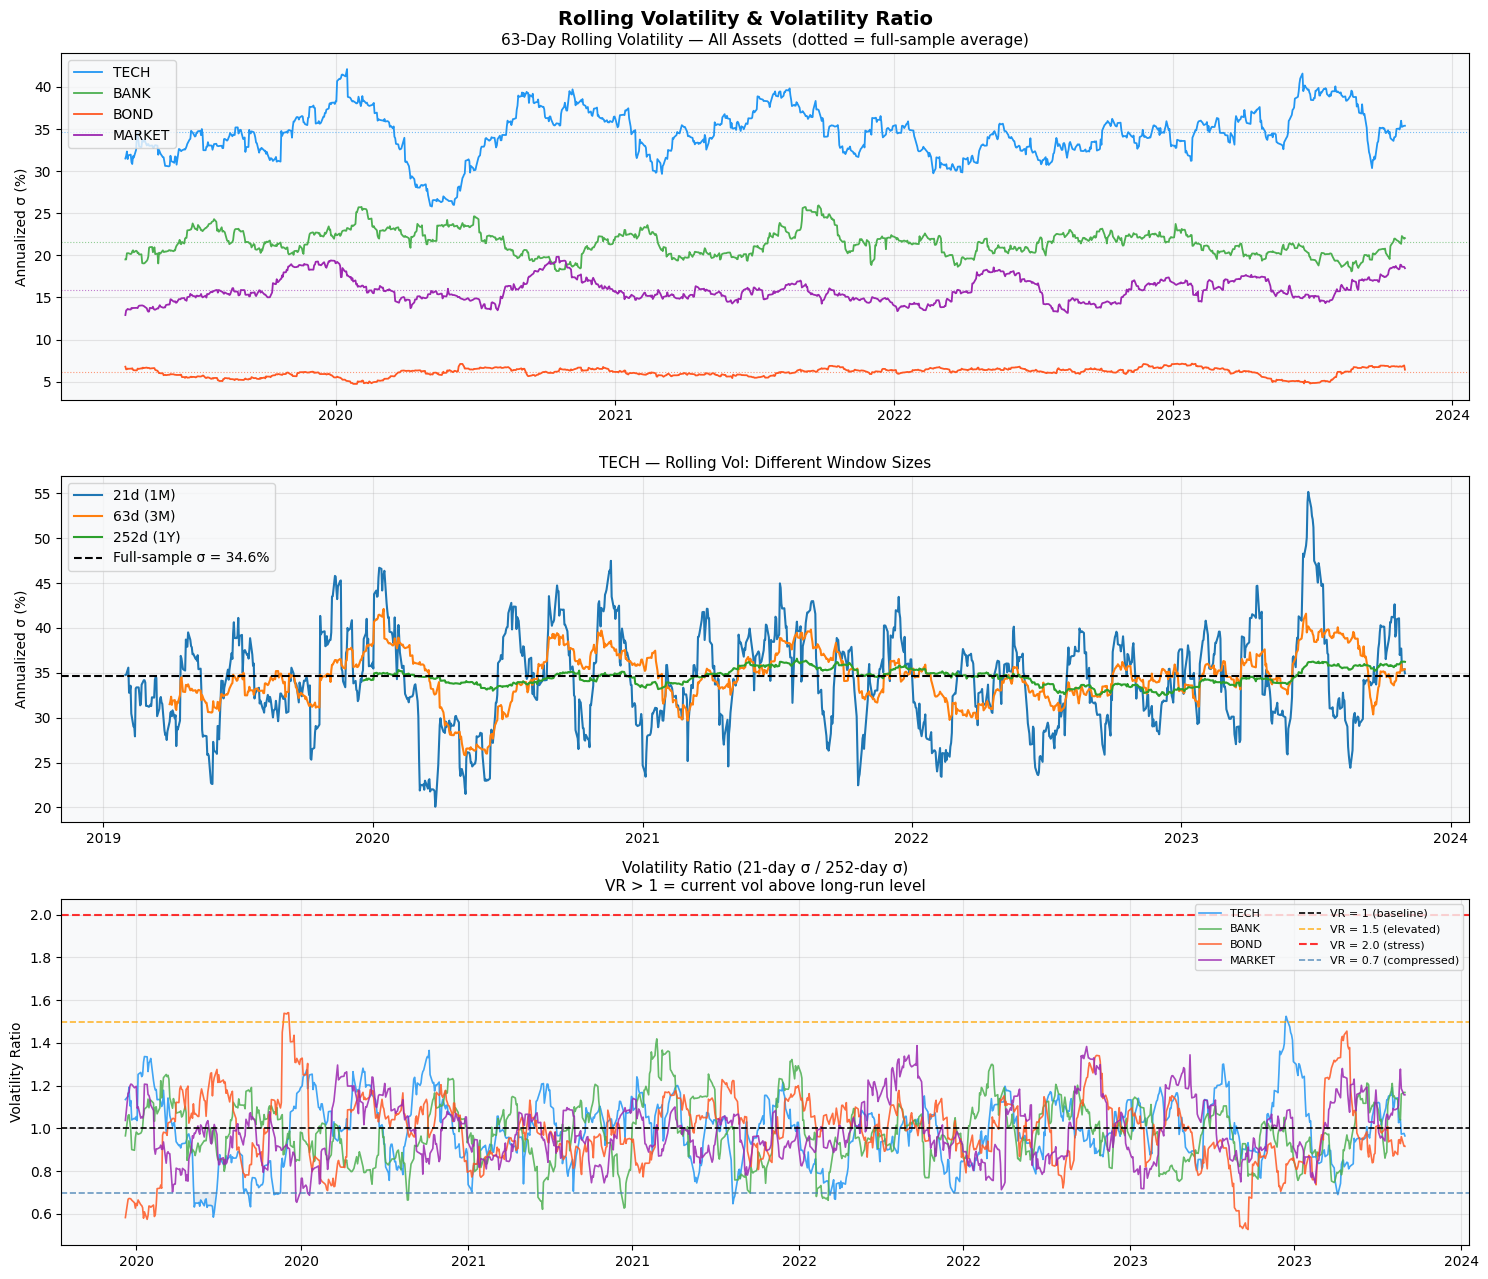

=== Volatility of Volatility (CoV of 63-day rolling vol) ===
Higher = more vol clustering / regime changes
  TECH    : 8.4%
  BANK    : 6.9%
  BOND    : 8.6%
  MARKET  : 9.0%

=== Volatility Ratio Regime Distribution (TECH) ===
Regime                      Days   % of time
─────────────────────────────────────────────
  Compressed (VR≤0.7)         35        3.5%
  Elevated (VR≥1.5)            2        0.2%
  Normal                     971       96.3%

=== Volatility Ratio Summary — All Assets ===
        Mean VR  Max VR  Min VR  Days VR>1.5  Days VR<0.7
TECH      0.992   1.525   0.585            2           35
BANK      0.985   1.419   0.621            0           17
BOND      0.992   1.541   0.527            4           39
MARKET    0.990   1.387   0.654            0            7


In [5]:
# ── Rolling Volatility ─────────────────────────────────────────────────────────
windows = {'21d (1M)': 21, '63d (3M)': 63, '252d (1Y)': 252}
roll_vol = {
    label: log_returns.rolling(w).std(ddof=1) * np.sqrt(252) * 100
    for label, w in windows.items()
}

rv_21  = log_returns.rolling(21).std(ddof=1)  * np.sqrt(252) * 100
rv_63  = log_returns.rolling(63).std(ddof=1)  * np.sqrt(252) * 100
rv_252 = log_returns.rolling(252).std(ddof=1) * np.sqrt(252) * 100

# ── Volatility Ratio: short-term / long-term ───────────────────────────────────
# VR > 1 → current vol is above its long-run level (stress)
# VR < 1 → calm / vol compression
vol_ratio = rv_21 / rv_252     # 21-day vs 252-day

# Regime labels based on VR thresholds
def vr_regime(vr):
    if vr >= 2.0:   return 'Stress (VR≥2)'
    elif vr >= 1.5: return 'Elevated (VR≥1.5)'
    elif vr <= 0.7: return 'Compressed (VR≤0.7)'
    else:           return 'Normal'

tech_vr = vol_ratio['TECH'].dropna()
regime_counts = tech_vr.apply(vr_regime).value_counts()

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 13))
fig.suptitle('Rolling Volatility & Volatility Ratio', fontsize=14, fontweight='bold')

# Plot 1: Rolling vol for all assets (63-day window)
for name, color in colors_map.items():
    axes[0].plot(rv_63.index, rv_63[name], label=name, color=color, lw=1.3)
for name, color in colors_map.items():
    axes[0].axhline(annual_std[name] * 100, color=color, lw=0.8, linestyle=':', alpha=0.6)
axes[0].set_title('63-Day Rolling Volatility — All Assets  (dotted = full-sample average)', fontsize=11)
axes[0].set_ylabel('Annualized σ (%)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Plot 2: Multiple windows for TECH only (window effect)
for label, rv_df in roll_vol.items():
    axes[1].plot(rv_df.index, rv_df['TECH'], label=label, lw=1.5)
axes[1].axhline(annual_std['TECH'] * 100, color='black', lw=1.5,
                linestyle='--', label=f'Full-sample σ = {annual_std["TECH"]*100:.1f}%')
axes[1].set_title('TECH — Rolling Vol: Different Window Sizes', fontsize=11)
axes[1].set_ylabel('Annualized σ (%)')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Plot 3: Volatility Ratio for all assets
for name, color in colors_map.items():
    axes[2].plot(vol_ratio.index, vol_ratio[name], label=name, color=color, lw=1.2, alpha=0.85)

# Threshold bands
axes[2].axhline(1.0, color='black',    lw=1.2, linestyle='--', label='VR = 1 (baseline)')
axes[2].axhline(1.5, color='orange',   lw=1.2, linestyle='--', alpha=0.8, label='VR = 1.5 (elevated)')
axes[2].axhline(2.0, color='red',      lw=1.5, linestyle='--', alpha=0.8, label='VR = 2.0 (stress)')
axes[2].axhline(0.7, color='steelblue',lw=1.2, linestyle='--', alpha=0.8, label='VR = 0.7 (compressed)')
axes[2].fill_between(vol_ratio.index, 1.5, vol_ratio['TECH'].clip(lower=0),
                     where=(vol_ratio['TECH'] >= 1.5),
                     color='red', alpha=0.08, label='_nolegend_')
axes[2].fill_between(vol_ratio.index, vol_ratio['TECH'].clip(upper=1.0), 0.7,
                     where=(vol_ratio['TECH'] <= 0.7),
                     color='steelblue', alpha=0.10, label='_nolegend_')
axes[2].set_title('Volatility Ratio (21-day σ / 252-day σ)\nVR > 1 = current vol above long-run level', fontsize=11)
axes[2].set_ylabel('Volatility Ratio')
axes[2].legend(fontsize=8, ncol=2)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

# ── Summary ────────────────────────────────────────────────────────────────────
print("=== Volatility of Volatility (CoV of 63-day rolling vol) ===")
print("Higher = more vol clustering / regime changes")
vol_of_vol = rv_63.std() / rv_63.mean() * 100
for name, cov in vol_of_vol.items():
    print(f"  {name:8s}: {cov:.1f}%")

print("\n=== Volatility Ratio Regime Distribution (TECH) ===")
print(f"{'Regime':<25} {'Days':>6}  {'% of time':>10}")
print("─" * 45)
for regime, count in regime_counts.sort_index().items():
    print(f"  {regime:<23} {count:>6}  {count/len(tech_vr)*100:>9.1f}%")

print(f"\n=== Volatility Ratio Summary — All Assets ===")
vr_stats = pd.DataFrame({
    'Mean VR':    vol_ratio.mean().round(3),
    'Max VR':     vol_ratio.max().round(3),
    'Min VR':     vol_ratio.min().round(3),
    'Days VR>1.5':vol_ratio.apply(lambda s: (s >= 1.5).sum()),
    'Days VR<0.7':vol_ratio.apply(lambda s: (s <= 0.7).sum()),
})
print(vr_stats.to_string())

## 6. Covariance — How Assets Move Together

While variance measures a single asset's variability, **covariance** captures whether two assets tend to move in the same direction at the same time:

$$\text{Cov}(R_i, R_j) = \frac{1}{T-1} \sum_{t=1}^{T} (r_{i,t} - \bar{r}_i)(r_{j,t} - \bar{r}_j)$$

| Covariance | Meaning |
|-----------|---------|
| $> 0$ | Assets tend to move together |
| $< 0$ | Assets tend to move in opposite directions (natural hedge) |
| $= 0$ | No linear co-movement (uncorrelated) |

### The Covariance Matrix
For $N$ assets, covariance is organized into an $N \times N$ **covariance matrix** $\Sigma$:
$$\Sigma = \begin{bmatrix} \sigma_1^2 & \sigma_{12} & \cdots \\ \sigma_{21} & \sigma_2^2 & \cdots \\ \vdots & \vdots & \ddots \end{bmatrix}$$

The diagonal contains each asset's variance; the off-diagonals contain pairwise covariances.

### Why It's Central to Portfolio Theory
**Portfolio variance** (Markowitz, 1952):
$$\sigma_p^2 = \mathbf{w}^\top \Sigma \mathbf{w} = \sum_i w_i^2 \sigma_i^2 + \sum_i \sum_{j \neq i} w_i w_j \sigma_{ij}$$

The second term shows that even if every asset has high variance, if covariances are low (or negative), the portfolio variance can be much lower. This is the mathematical basis of **diversification**.

### Beginner Explanation

Covariance tells us whether two assets usually move in the same direction or in opposite directions. It is the first step toward understanding diversification.

If two risky assets do not move together perfectly, combining them can reduce overall portfolio risk. That is why covariance matters so much in portfolio theory.

Manual Cov(TECH, MARKET) annual: 0.000455
Matrix  Cov(TECH, MARKET) annual: 0.000455  ✓



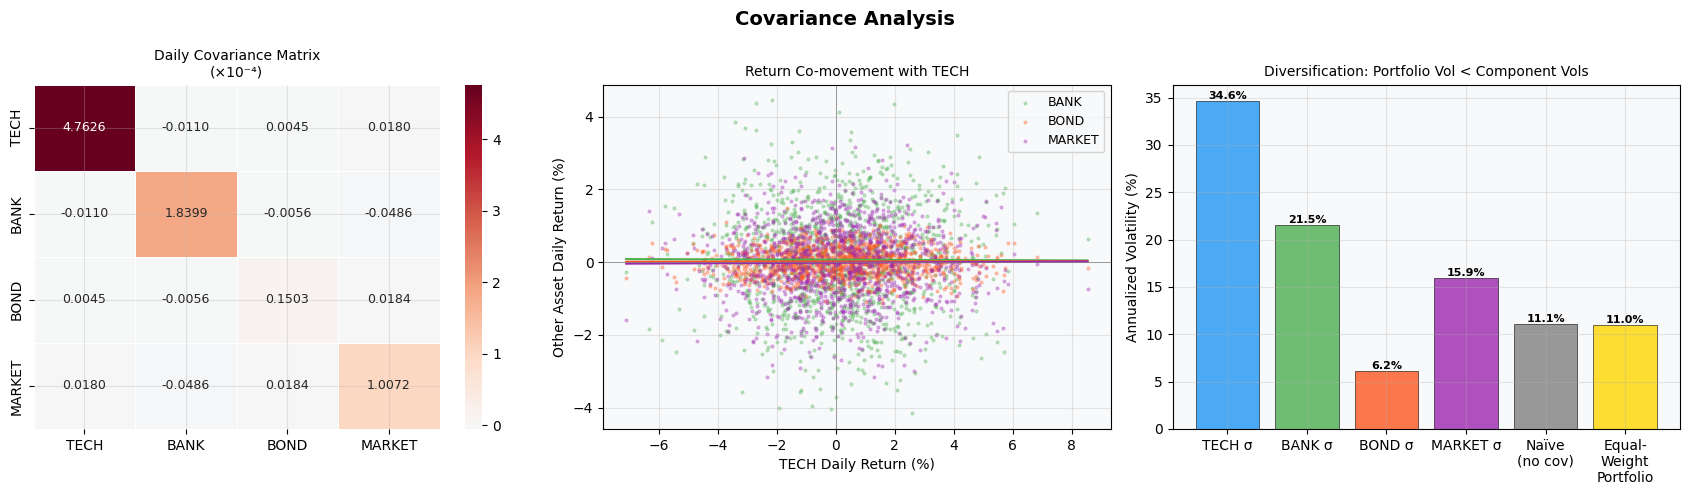


=== Diversification Benefit ===
Naïve portfolio vol (ignoring covariances): 11.06%
Actual equal-weight portfolio vol:          11.02%
Reduction from diversification:             0.03%


In [6]:
# ── Covariance Matrix ──────────────────────────────────────────────────────────
cov_matrix = log_returns.cov() * 252      # annualized covariance matrix

# Manual check for TECH-MARKET covariance
tech_r  = log_returns['TECH']
mkt_r   = log_returns['MARKET']
manual_cov = ((tech_r - tech_r.mean()) * (mkt_r - mkt_r.mean())).sum() / (len(tech_r) - 1) * 252
print(f"Manual Cov(TECH, MARKET) annual: {manual_cov:.6f}")
print(f"Matrix  Cov(TECH, MARKET) annual: {cov_matrix.loc['TECH','MARKET']:.6f}  ✓\n")

# ── Portfolio variance demonstration ──────────────────────────────────────────
# Equal weight portfolio
n_assets = len(log_returns.columns)
w_equal = np.array([1/n_assets] * n_assets)
port_var_equal = w_equal @ cov_matrix.values @ w_equal
port_std_equal = np.sqrt(port_var_equal)

# Weighted sum of individual variances (ignoring covariance — WRONG approach)
naive_var = np.sum(w_equal**2 * np.diag(cov_matrix.values))
naive_std = np.sqrt(naive_var)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Covariance Analysis', fontsize=14, fontweight='bold')

# Plot 1: Covariance matrix heatmap (daily to be readable)
cov_daily = log_returns.cov() * 1e4   # ×10,000 scaling for readability
mask = np.zeros_like(cov_daily, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(cov_daily, ax=axes[0], annot=True, fmt='.4f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            annot_kws={'size': 9})
axes[0].set_title('Daily Covariance Matrix\n(×10⁻⁴)', fontsize=10)

# Plot 2: Scatter plots of returns (TECH vs others)
scatter_assets = ['BANK', 'BOND', 'MARKET']
scatter_colors = ['#4CAF50', '#FF5722', '#9C27B0']
for i, (other, sc) in enumerate(zip(scatter_assets, scatter_colors)):
    axes[1].scatter(log_returns['TECH'] * 100, log_returns[other] * 100,
                    s=4, alpha=0.3, color=sc, label=other)
    # Add regression line
    z = np.polyfit(log_returns['TECH'], log_returns[other], 1)
    xfit = np.linspace(log_returns['TECH'].min(), log_returns['TECH'].max(), 100)
    axes[1].plot(xfit * 100, np.poly1d(z)(xfit) * 100, color=sc, lw=1.5)

axes[1].set_xlabel('TECH Daily Return (%)')
axes[1].set_ylabel('Other Asset Daily Return (%)')
axes[1].set_title('Return Co-movement with TECH', fontsize=10)
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].axvline(0, color='gray', lw=0.5)
axes[1].legend(fontsize=9)

# Plot 3: Diversification benefit bar chart
labels = ['TECH σ', 'BANK σ', 'BOND σ', 'MARKET σ', 'Naïve\n(no cov)', 'Equal-\nWeight\nPortfolio']
values = list(annual_std * 100) + [naive_std * 100, port_std_equal * 100]
bar_colors = list(colors_map.values()) + ['gray', 'gold']
bars = axes[2].bar(labels, values, color=bar_colors, alpha=0.8, edgecolor='black', lw=0.5)
axes[2].set_ylabel('Annualized Volatility (%)')
axes[2].set_title('Diversification: Portfolio Vol < Component Vols', fontsize=10)
for bar, val in zip(bars, values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n=== Diversification Benefit ===")
print(f"Naïve portfolio vol (ignoring covariances): {naive_std*100:.2f}%")
print(f"Actual equal-weight portfolio vol:          {port_std_equal*100:.2f}%")
print(f"Reduction from diversification:             {(naive_std - port_std_equal)*100:.2f}%")

## 7. Correlation — Normalized Co-Movement

Covariance has a units problem: $\text{Cov}(\text{TECH, MARKET})$ is in units of *return²*, making it hard to interpret or compare. **Correlation** normalizes covariance to a dimensionless $[-1, +1]$ scale:

$$\rho_{ij} = \frac{\text{Cov}(R_i, R_j)}{\sigma_i \cdot \sigma_j}$$

| Value | Interpretation |
|-------|---------------|
| $\rho = +1$ | Perfect positive co-movement |
| $\rho = +0.7$ | Strong positive (typical equities in same sector) |
| $\rho \approx 0$ | No linear relationship |
| $\rho = -0.5$ | Moderate negative (equity + bond in normal regime) |
| $\rho = -1$ | Perfect hedge |

### Reversing: Covariance from Correlation
$$\text{Cov}(R_i, R_j) = \rho_{ij} \cdot \sigma_i \cdot \sigma_j$$

This is widely used in risk systems: a correlation matrix $\mathbf{C}$ is estimated separately from volatilities $\sigma_i$, then recombined into $\Sigma$:
$$\Sigma = D \cdot \mathbf{C} \cdot D \quad \text{where } D = \text{diag}(\sigma_1, \ldots, \sigma_N)$$

### Important Caveats
1. **Correlation ≠ Causation**: Two assets may correlate for spurious reasons.
2. **Correlation is not stable**: Correlations between equities and bonds can flip from negative to positive during crises ("correlation breakdown").
3. **Non-linearity**: Correlation only captures *linear* relationships. Two assets can have $\rho=0$ yet be strongly dependent (e.g., tail dependence).

### Beginner Explanation

Correlation is a cleaned-up version of covariance. It tells us how strongly two assets move together on a standard scale from -1 to +1, which makes it much easier to interpret.

A positive correlation means assets usually move in the same direction. A negative correlation means they offset each other. A near-zero correlation means there is little linear relationship.

Manual ρ(TECH, MARKET): 0.008237
Pandas ρ(TECH, MARKET): 0.008237  ✓



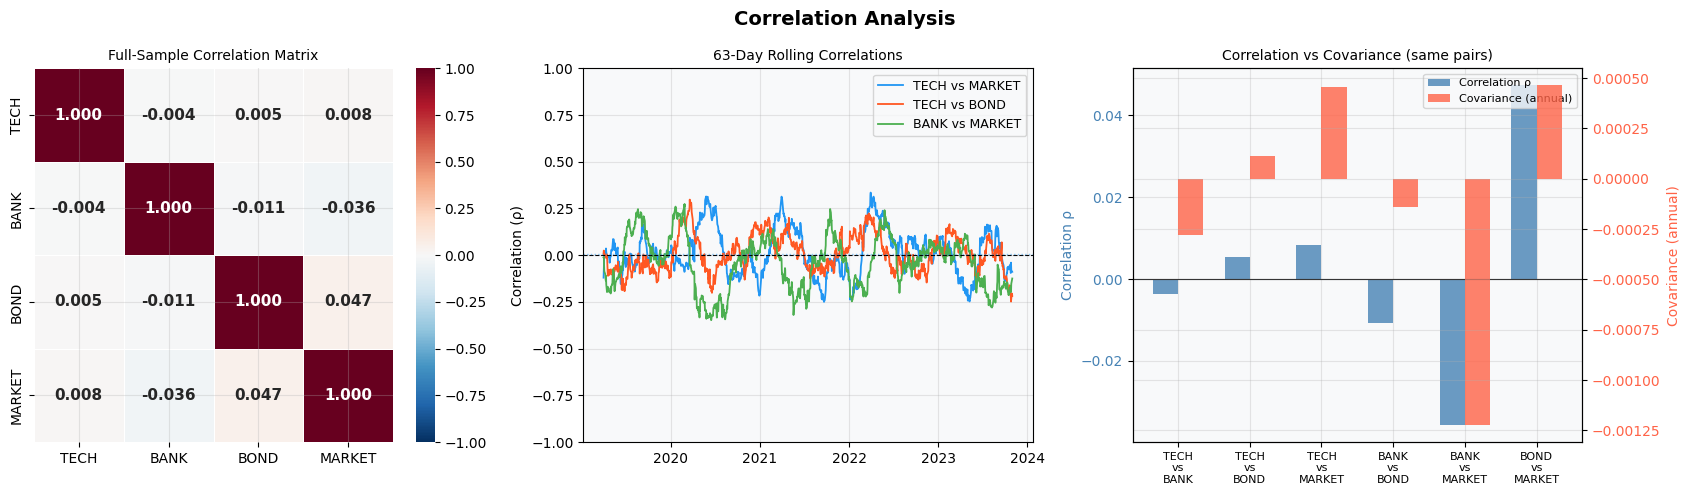

=== Pairwise Correlation Summary ===
          TECH    BANK    BOND  MARKET
TECH    1.0000 -0.0037  0.0053  0.0082
BANK   -0.0037  1.0000 -0.0107 -0.0357
BOND    0.0053 -0.0107  1.0000  0.0473
MARKET  0.0082 -0.0357  0.0473  1.0000


In [7]:
# ── Correlation Matrix ─────────────────────────────────────────────────────────
corr_matrix = log_returns.corr()

# Manual verification
manual_corr_tm = (
    cov_matrix.loc['TECH','MARKET']
    / (annual_std['TECH'] * annual_std['MARKET'])
)
print(f"Manual ρ(TECH, MARKET): {manual_corr_tm:.6f}")
print(f"Pandas ρ(TECH, MARKET): {corr_matrix.loc['TECH','MARKET']:.6f}  ✓\n")

# ── Rolling correlation (TECH vs MARKET, 63-day window) ───────────────────────
roll_corr_tm = log_returns['TECH'].rolling(63).corr(log_returns['MARKET'])
roll_corr_tb = log_returns['TECH'].rolling(63).corr(log_returns['BOND'])
roll_corr_bm = log_returns['BANK'].rolling(63).corr(log_returns['MARKET'])

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Correlation Analysis', fontsize=14, fontweight='bold')

# Plot 1: Full-sample correlation heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, ax=axes[0], annot=True, fmt='.3f',
            cmap='RdBu_r', vmin=-1, vmax=1, center=0,
            linewidths=0.5, annot_kws={'size': 11, 'weight': 'bold'})
axes[0].set_title('Full-Sample Correlation Matrix', fontsize=10)

# Plot 2: Rolling correlations over time
axes[1].plot(roll_corr_tm.index, roll_corr_tm, label='TECH vs MARKET', color='#2196F3', lw=1.3)
axes[1].plot(roll_corr_tb.index, roll_corr_tb, label='TECH vs BOND',   color='#FF5722', lw=1.3)
axes[1].plot(roll_corr_bm.index, roll_corr_bm, label='BANK vs MARKET', color='#4CAF50', lw=1.3)
axes[1].axhline(0, color='black', lw=0.8, linestyle='--')
axes[1].axhline(corr_matrix.loc['TECH','MARKET'], color='#2196F3',
                lw=1, linestyle=':', alpha=0.5)
axes[1].set_title('63-Day Rolling Correlations', fontsize=10)
axes[1].set_ylabel('Correlation (ρ)')
axes[1].set_ylim(-1, 1)
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Plot 3: Correlation vs covariance (intuition: normalize)
# Show same pairs — compare raw cov vs normalized corr
pairs = [('TECH','BANK'), ('TECH','BOND'), ('TECH','MARKET'), ('BANK','BOND'), ('BANK','MARKET'), ('BOND','MARKET')]
cov_vals  = [cov_matrix.loc[a,b] for a, b in pairs]
corr_vals = [corr_matrix.loc[a,b] for a, b in pairs]
pair_labels = [f'{a}\nvs\n{b}' for a, b in pairs]

x = np.arange(len(pairs))
width = 0.35
ax3 = axes[2]
ax3b = ax3.twinx()
bars1 = ax3.bar(x - width/2, corr_vals, width, label='Correlation ρ', color='steelblue', alpha=0.8)
bars2 = ax3b.bar(x + width/2, cov_vals, width, label='Covariance (annual)', color='tomato', alpha=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(pair_labels, fontsize=8)
ax3.set_ylabel('Correlation ρ', color='steelblue')
ax3b.set_ylabel('Covariance (annual)', color='tomato')
ax3.tick_params(axis='y', labelcolor='steelblue')
ax3b.tick_params(axis='y', labelcolor='tomato')
ax3.axhline(0, color='black', lw=0.8)
ax3.set_title('Correlation vs Covariance (same pairs)', fontsize=10)
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

# Full correlation table
print("=== Pairwise Correlation Summary ===")
print(corr_matrix.round(4).to_string())

## 8. Beta (β) — Market Sensitivity

Beta is one of the most important concepts in finance — it measures how much an asset moves *relative to the market*:

$$\beta_i = \frac{\text{Cov}(R_i, R_m)}{\text{Var}(R_m)} = \frac{\sigma_{im}}{\sigma_m^2} = \rho_{im} \cdot \frac{\sigma_i}{\sigma_m}$$

### Interpretation
| Beta | Meaning | Example |
|------|---------|---------|
| $\beta = 1.0$ | Moves exactly with the market | Index ETF |
| $\beta > 1$ (aggressive) | Amplifies market moves | TECH stocks, small-caps |
| $0 < \beta < 1$ (defensive) | Less volatile than market | Utilities, consumer staples |
| $\beta = 0$ | No market sensitivity | T-Bills, delta-neutral hedge |
| $\beta < 0$ | Moves opposite market (hedge) | Gold, VIX, long puts |

### CAPM: Risk Decomposition
CAPM decomposes total risk into **systematic** (unavoidable, market) and **idiosyncratic** (diversifiable):
$$\underbrace{\sigma_i^2}_{\text{Total Risk}} = \underbrace{\beta_i^2 \sigma_m^2}_{\text{Systematic Risk}} + \underbrace{\sigma_{\varepsilon_i}^2}_{\text{Idiosyncratic Risk}}$$

Only systematic risk earns a risk premium in equilibrium — idiosyncratic risk can be diversified away for free.

### Industry Uses
- **Risk attribution**: Break portfolio risk into factor (systematic) and specific (idiosyncratic) components
- **Hedge construction**: To hedge 100 shares of TECH with beta=2.0 against the market, short 200 units of the market ETF
- **Expected return**: $E[R_i] = R_f + \beta_i (E[R_m] - R_f)$

### Beginner Explanation

Beta compares one asset to the market. It answers the question: **if the market moves by 1%, how much does this asset tend to move?**

So beta is really a sensitivity measure:

- above 1 means the asset tends to move more than the market
- below 1 means it tends to move less
- negative beta means it tends to move against the market

Manual β(TECH): 0.0179
OLS    β(TECH): 0.0179  ✓



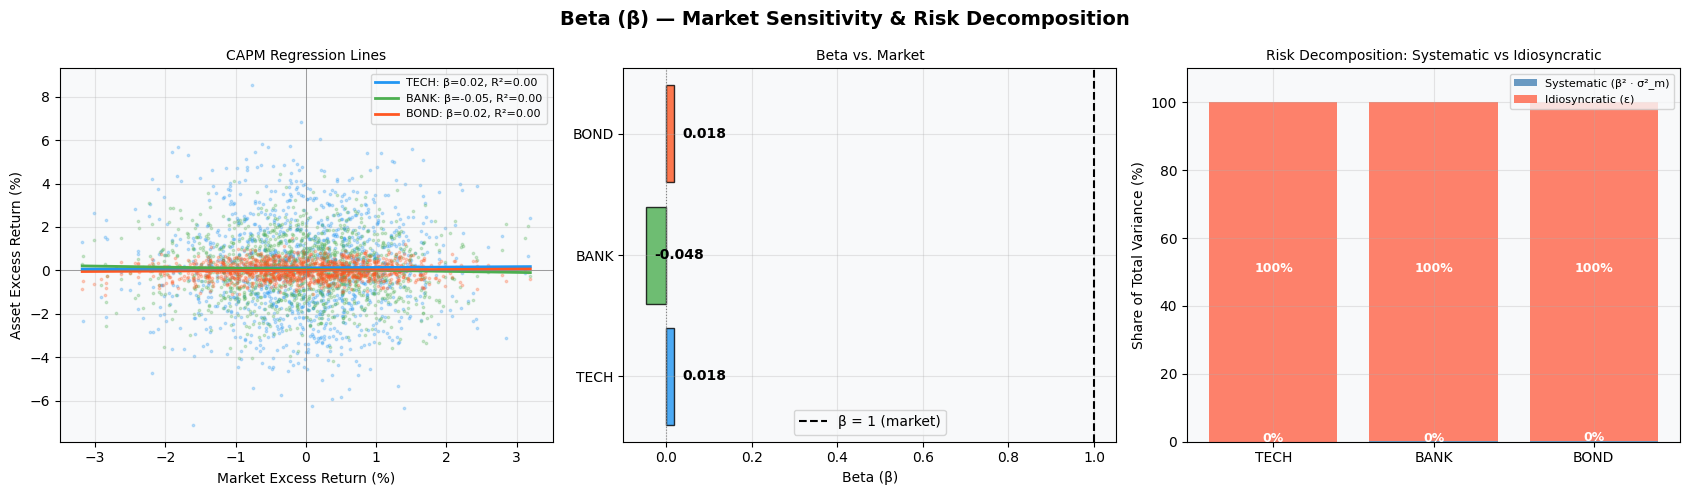

=== Beta Summary ===
TECH  : β=0.018  α(daily)=11.50bps  R²=0.000  Systematic=0%  Idiosyncratic=100%
BANK  : β=-0.048  α(daily)=5.06bps  R²=0.001  Systematic=0%  Idiosyncratic=100%
BOND  : β=0.018  α(daily)=0.29bps  R²=0.002  Systematic=0%  Idiosyncratic=100%


In [8]:
# ── Beta Calculation (numpy-based OLS — no statsmodels dependency) ─────────────
mkt = log_returns['MARKET']
rf_daily = 0.04 / 252  # assume 4% annual risk-free rate

betas = {}
alphas = {}
r_squared = {}

for name in ['TECH', 'BANK', 'BOND']:
    excess_asset = log_returns[name] - rf_daily
    excess_mkt   = mkt - rf_daily

    # OLS via Cov/Var (identical to sm.OLS result)
    beta  = excess_asset.cov(excess_mkt) / excess_mkt.var(ddof=1)
    alpha = excess_asset.mean() - beta * excess_mkt.mean()

    # R² = 1 - SS_res / SS_tot
    y_hat   = alpha + beta * excess_mkt
    ss_res  = ((excess_asset - y_hat) ** 2).sum()
    ss_tot  = ((excess_asset - excess_asset.mean()) ** 2).sum()
    r2      = 1 - ss_res / ss_tot

    betas[name]     = beta
    alphas[name]    = alpha
    r_squared[name] = r2

# Manual beta verification
manual_beta_tech = cov_matrix.loc['TECH','MARKET'] / cov_matrix.loc['MARKET','MARKET']
print(f"Manual β(TECH): {manual_beta_tech:.4f}")
print(f"OLS    β(TECH): {betas['TECH']:.4f}  ✓\n")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Beta (β) — Market Sensitivity & Risk Decomposition', fontsize=14, fontweight='bold')

# Plot 1: Beta scatter plots (CAPM regression line)
for name, color in [('TECH','#2196F3'), ('BANK','#4CAF50'), ('BOND','#FF5722')]:
    excess_asset = (log_returns[name] - rf_daily) * 100
    excess_mkt_pct = (mkt - rf_daily) * 100
    axes[0].scatter(excess_mkt_pct, excess_asset, s=3, alpha=0.25, color=color)
    x_fit = np.linspace(excess_mkt_pct.min(), excess_mkt_pct.max(), 100)
    y_fit = alphas[name]*100 + betas[name] * x_fit
    axes[0].plot(x_fit, y_fit, color=color, lw=2,
                 label=f'{name}: β={betas[name]:.2f}, R²={r_squared[name]:.2f}')

axes[0].axhline(0, color='gray', lw=0.5)
axes[0].axvline(0, color='gray', lw=0.5)
axes[0].set_xlabel('Market Excess Return (%)')
axes[0].set_ylabel('Asset Excess Return (%)')
axes[0].set_title('CAPM Regression Lines', fontsize=10)
axes[0].legend(fontsize=8)

# Plot 2: Beta bar chart
asset_names = list(betas.keys())
beta_vals = [betas[n] for n in asset_names]
bar_colors2 = ['#2196F3', '#4CAF50', '#FF5722']
bars = axes[1].barh(asset_names, beta_vals, color=bar_colors2, alpha=0.8, edgecolor='black')
axes[1].axvline(1.0, color='black', lw=1.5, linestyle='--', label='β = 1 (market)')
axes[1].axvline(0.0, color='gray',  lw=0.8, linestyle=':')
for bar, val in zip(bars, beta_vals):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Beta (β)')
axes[1].set_title('Beta vs. Market', fontsize=10)
axes[1].legend()

# Plot 3: Risk decomposition (systematic vs idiosyncratic)
systematic_vars = {n: betas[n]**2 * mkt.var(ddof=1) * 252 for n in asset_names}
idio_vars = {n: max(annual_var[n] - systematic_vars[n], 0) for n in asset_names}

syst_pct = {n: systematic_vars[n] / annual_var[n] * 100 for n in asset_names}
idio_pct = {n: idio_vars[n] / annual_var[n] * 100 for n in asset_names}

x = np.arange(len(asset_names))
axes[2].bar(x, [syst_pct[n] for n in asset_names],
            label='Systematic (β² · σ²_m)', color='steelblue', alpha=0.8)
axes[2].bar(x, [idio_pct[n] for n in asset_names],
            bottom=[syst_pct[n] for n in asset_names],
            label='Idiosyncratic (ε)', color='tomato', alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(asset_names)
axes[2].set_ylabel('Share of Total Variance (%)')
axes[2].set_title('Risk Decomposition: Systematic vs Idiosyncratic', fontsize=10)
axes[2].legend(fontsize=8)
axes[2].set_ylim(0, 110)
for i, n in enumerate(asset_names):
    axes[2].text(i, syst_pct[n]/2, f"{syst_pct[n]:.0f}%", ha='center', fontsize=9, color='white', fontweight='bold')
    axes[2].text(i, syst_pct[n] + idio_pct[n]/2, f"{idio_pct[n]:.0f}%", ha='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print("=== Beta Summary ===")
for n in asset_names:
    print(f"{n:6s}: β={betas[n]:.3f}  α(daily)={alphas[n]*10000:.2f}bps  "
          f"R²={r_squared[n]:.3f}  Systematic={syst_pct[n]:.0f}%  Idiosyncratic={idio_pct[n]:.0f}%")

## 9. Value at Risk (VaR) & Expected Shortfall (CVaR)

**Risk managers must answer**: "How much could we lose in a bad day (or month)?"  
VaR quantifies this in probabilistic terms.

### Value at Risk (VaR)
$$\text{VaR}_\alpha = -\text{Quantile}_\alpha(R)$$

At confidence level $\alpha$ (e.g., 95%), VaR is the loss threshold we expect to *NOT exceed* with probability $\alpha$.

**Example**: Daily VaR₉₅ = $1M means: "We expect our losses will be less than $1M on 95% of trading days. On the remaining 5% of days, losses may exceed $1M."

### Three Methods to Compute VaR
| Method | How | Assumption |
|--------|-----|-----------|
| **Historical** | Sort past returns, take 5th percentile | Non-parametric, data-driven |
| **Parametric** | $\text{VaR} = -(\mu - z_\alpha \sigma)$ | Returns are normally distributed |
| **Monte Carlo** | Simulate many scenarios | Flexible, any distribution |

### Expected Shortfall (CVaR / ES)
$$\text{ES}_\alpha = -E[R \mid R < -\text{VaR}_\alpha]$$

ES is the *average loss conditional on exceeding VaR*. It answers "how bad is the average tail loss?" and is more coherent than VaR as a risk measure (it accounts for the full shape of the tail).

### Regulatory Context
- Basel III (2022): Banks moved from VaR to **ES at 97.5%** for internal model capital requirements
- FRTB (Fundamental Review of the Trading Book): ES with stressed calibration period

### Beginner Explanation

VaR and Expected Shortfall are both about downside risk. They do not ask what your average return is. They ask **how bad losses can get when things go wrong**.

A simple way to separate them is:

- **VaR** = the loss threshold you expect not to exceed most of the time
- **ES / CVaR** = the average loss once you have already crossed that bad threshold

So ES is usually more severe and more informative about the tail.

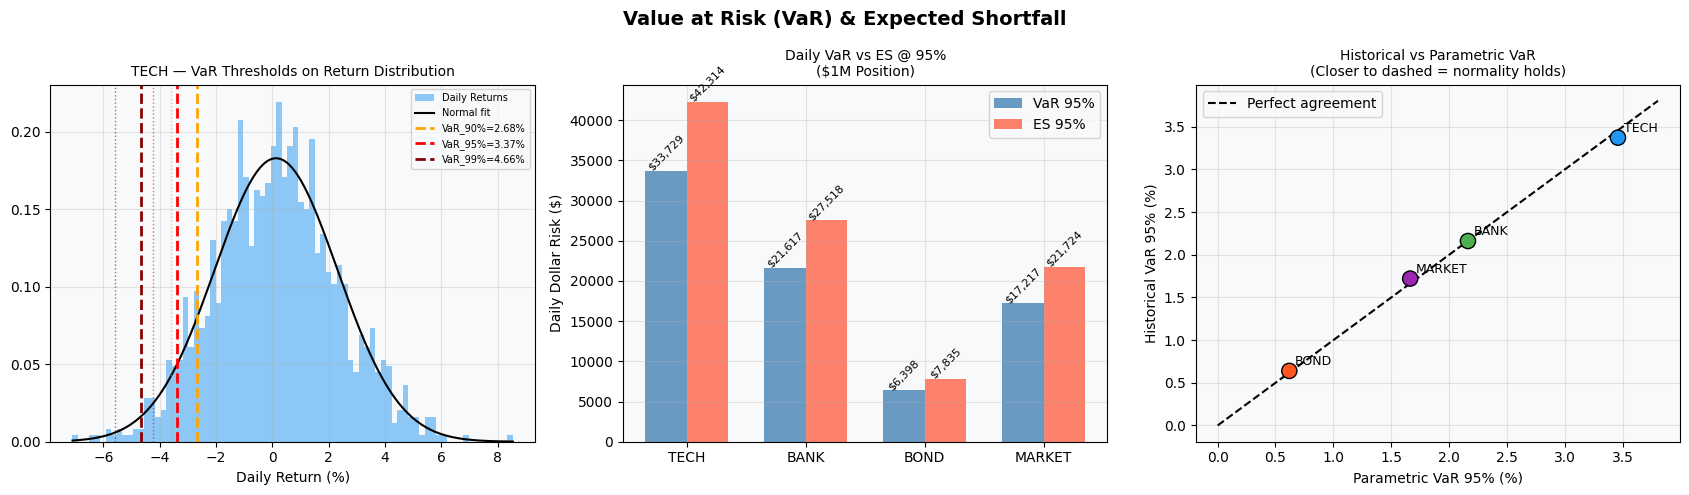

=== VaR & ES Summary (% of portfolio, daily) ===
        Hist VaR 90%  Hist VaR 95%  Hist VaR 99%  ES 95%
TECH          2.6847        3.3729        4.6629  4.2314
BANK          1.6752        2.1617        3.1910  2.7518
BOND          0.4691        0.6398        0.8451  0.7835
MARKET        1.3339        1.7217        2.3908  2.1724


In [9]:
# ── VaR & Expected Shortfall ───────────────────────────────────────────────────
confidence_levels = [0.90, 0.95, 0.99]
portfolio_value = 1_000_000  # $1M portfolio

def historical_var(returns, alpha):
    """Historical VaR at (1-alpha) confidence — e.g. alpha=0.05 → VaR95"""
    return -np.percentile(returns, (1 - alpha) * 100)

def historical_es(returns, alpha):
    """Expected Shortfall: mean of losses beyond VaR"""
    var = historical_var(returns, alpha)
    tail = returns[returns < -var]
    return -tail.mean() if len(tail) > 0 else var

def parametric_var(returns, alpha):
    mu, sigma = returns.mean(), returns.std(ddof=1)
    z = stats.norm.ppf(1 - alpha)
    return -(mu + z * sigma)

# Compute for all assets and confidence levels
var_table = {}
for name in log_returns.columns:
    r = log_returns[name]
    var_table[name] = {
        f'Hist VaR {int(cl*100)}%': historical_var(r, cl) * 100
        for cl in confidence_levels
    }
    for cl in confidence_levels:
        var_table[name][f'ES {int(cl*100)}%'] = historical_es(r, cl) * 100
        var_table[name][f'Param VaR {int(cl*100)}%'] = parametric_var(r, cl) * 100

var_df = pd.DataFrame(var_table).T

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Value at Risk (VaR) & Expected Shortfall', fontsize=14, fontweight='bold')

# Plot 1: Return distribution with VaR/ES marked (TECH)
asset = 'TECH'
r_pct = log_returns[asset] * 100
axes[0].hist(r_pct, bins=80, density=True, color='#2196F3', alpha=0.5, label='Daily Returns')
x_range = np.linspace(r_pct.min(), r_pct.max(), 300)
axes[0].plot(x_range, stats.norm.pdf(x_range, r_pct.mean(), r_pct.std()), 'k-', lw=1.5, label='Normal fit')

cl_colors = ['orange', 'red', 'darkred']
for cl, col in zip(confidence_levels, cl_colors):
    v = historical_var(log_returns[asset], cl) * 100
    e = historical_es(log_returns[asset], cl) * 100
    axes[0].axvline(-v, color=col, lw=2, linestyle='--', label=f'VaR_{int(cl*100)}%={v:.2f}%')
    axes[0].axvline(-e, color=col, lw=1, linestyle=':', alpha=0.6)

axes[0].set_xlabel('Daily Return (%)')
axes[0].set_title(f'{asset} — VaR Thresholds on Return Distribution', fontsize=10)
axes[0].legend(fontsize=7)

# Plot 2: VaR ($) across assets at 95%
var95_dollars = {name: historical_var(log_returns[name], 0.95) * portfolio_value
                 for name in log_returns.columns}
es95_dollars  = {name: historical_es(log_returns[name], 0.95) * portfolio_value
                 for name in log_returns.columns}

x = np.arange(len(log_returns.columns))
width = 0.35
axes[1].bar(x - width/2, list(var95_dollars.values()), width,
            label='VaR 95%', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, list(es95_dollars.values()), width,
            label='ES 95%', color='tomato', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(log_returns.columns)
axes[1].set_ylabel('Daily Dollar Risk ($)')
axes[1].set_title('Daily VaR vs ES @ 95%\n($1M Position)', fontsize=10)
axes[1].legend()
for i, (v, e) in enumerate(zip(var95_dollars.values(), es95_dollars.values())):
    axes[1].text(i - width/2, v + 50, f'${v:,.0f}', ha='center', fontsize=8, rotation=45)
    axes[1].text(i + width/2, e + 50, f'${e:,.0f}', ha='center', fontsize=8, rotation=45)

# Plot 3: VaR comparison — Historical vs Parametric (at 95%, all assets)
hist_var95   = [historical_var(log_returns[n], 0.95) * 100 for n in log_returns.columns]
param_var95  = [parametric_var(log_returns[n], 0.95)  * 100 for n in log_returns.columns]
axes[2].scatter(param_var95, hist_var95, s=120, zorder=5,
                c=list(colors_map.values()), edgecolors='black', lw=1)
lim = max(max(hist_var95), max(param_var95)) * 1.1
axes[2].plot([0, lim], [0, lim], 'k--', lw=1.5, label='Perfect agreement')
for name, hv, pv in zip(log_returns.columns, hist_var95, param_var95):
    axes[2].annotate(name, (pv, hv), xytext=(4, 4), textcoords='offset points', fontsize=9)
axes[2].set_xlabel('Parametric VaR 95% (%)')
axes[2].set_ylabel('Historical VaR 95% (%)')
axes[2].set_title('Historical vs Parametric VaR\n(Closer to dashed = normality holds)', fontsize=10)
axes[2].legend()

plt.tight_layout()
plt.show()

print("=== VaR & ES Summary (% of portfolio, daily) ===")
cols_show = [f'Hist VaR {int(cl*100)}%' for cl in confidence_levels] + \
            [f'ES {int(cl*100)}%' for cl in [0.95]]
print(var_df[cols_show].round(4).to_string())

## 10. Drawdown — Measuring Peak-to-Trough Losses

While volatility measures the *dispersion* of returns, **drawdown** measures the *path* — specifically how far you fall from a previous high. Investors experience drawdowns emotionally; a strategy with lower volatility but a 50% drawdown is far more dangerous to hold than one with slightly higher volatility and only 15% max drawdown.

### Definitions
**Drawdown at time $t$**:
$$\text{DD}_t = \frac{P_t - \max_{s \leq t}(P_s)}{\max_{s \leq t}(P_s)}$$

**Maximum Drawdown (MDD)**: the worst peak-to-trough decline over the entire history:
$$\text{MDD} = \min_t \left(\text{DD}_t\right) = \min_t \left(\frac{P_t - \max_{s \leq t}P_s}{\max_{s \leq t}P_s}\right)$$

### Why Drawdowns Matter
- **Investor psychology**: Investors tend to panic-sell at drawdown troughs, crystallizing losses. The 2008 GFC produced 55% drawdown in the S&P 500 — most retail investors sold near the bottom.
- **Margin calls**: Leveraged portfolios may face forced liquidation when drawdown exceeds a maintenance margin threshold, regardless of long-term expected value.
- **Calmar Ratio**: Annualized return divided by Maximum Drawdown — a risk-adjusted metric that penalizes for deep drawdowns:
$$\text{Calmar} = \frac{\text{CAGR}}{|\text{MDD}|}$$

### Beginner Explanation

Drawdown is different from volatility. Volatility measures day-to-day fluctuation, but drawdown measures the pain of falling from a previous high.

This makes drawdown easier to relate to as an investor, because it answers a direct question: **how far did my portfolio fall before it recovered?**

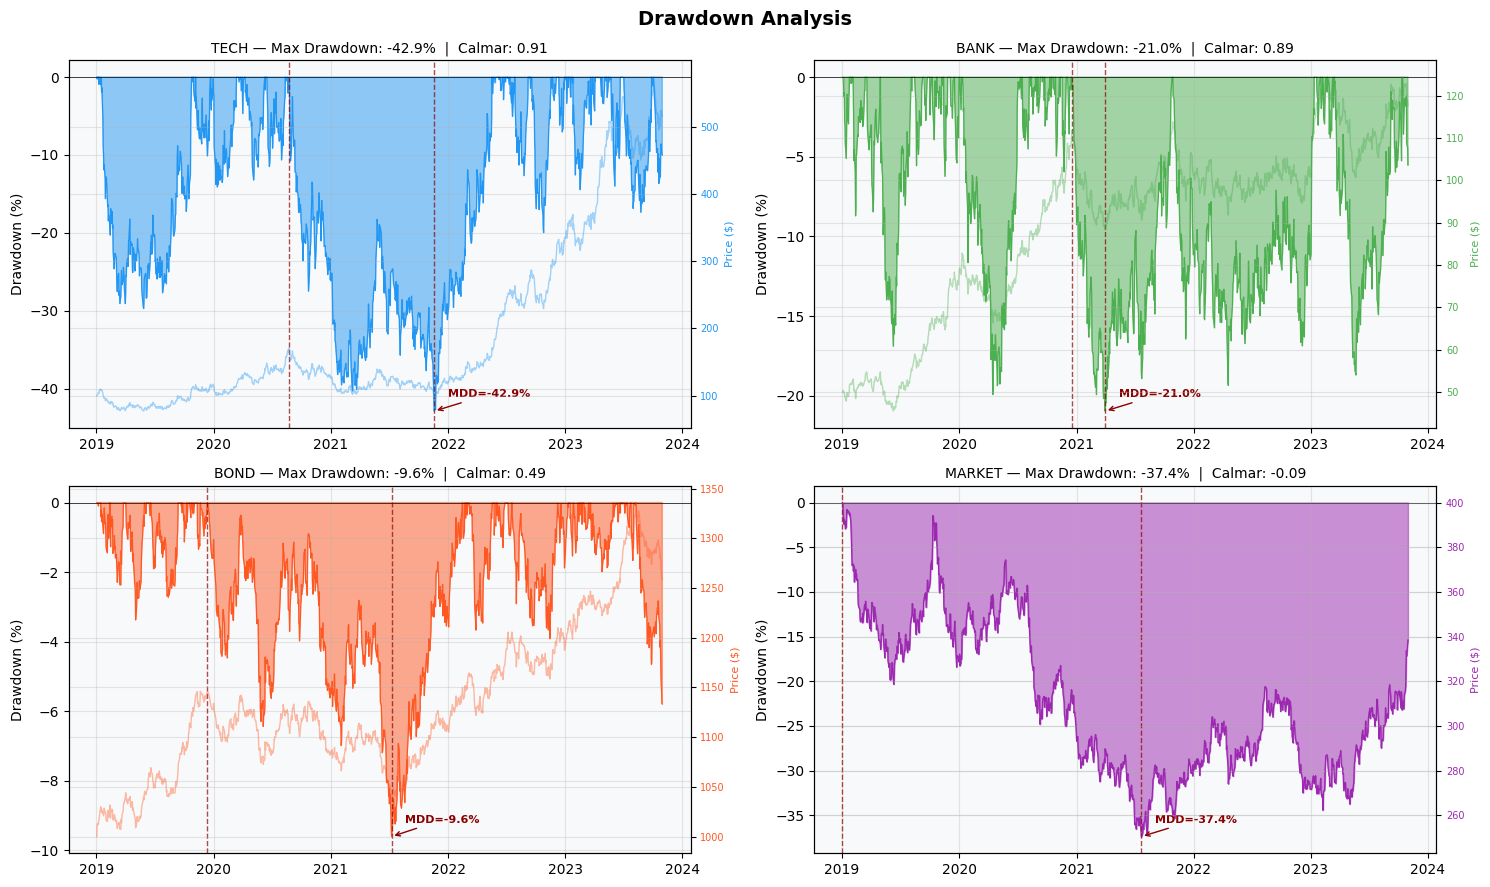

=== Drawdown Summary ===
Asset          Max DD    MDD Start      MDD End     CAGR   Calmar
─────────────────────────────────────────────────────────────────
TECH          -42.85%    2020-08-24   2021-11-19   38.89%     0.91
BANK          -20.95%    2020-12-17   2021-03-31   18.66%     0.89
BOND           -9.60%    2019-12-13   2021-07-09    4.71%     0.49
MARKET        -37.37%    2019-01-02   2021-07-22   -3.29%    -0.09


In [10]:
# ── Drawdown Analysis ──────────────────────────────────────────────────────────
def compute_drawdown(price_series):
    """Returns drawdown series and max drawdown for a price series."""
    rolling_max = price_series.cummax()
    drawdown = (price_series - rolling_max) / rolling_max
    max_dd = drawdown.min()
    max_dd_end = drawdown.idxmin()
    max_dd_start = price_series[:max_dd_end].idxmax()
    return drawdown, max_dd, max_dd_start, max_dd_end

# Compute for all assets
drawdown_data = {}
for name in df_prices.columns:
    dd, mdd, mdd_start, mdd_end = compute_drawdown(df_prices[name])
    calmar = cagr[name] / abs(mdd) if mdd != 0 else np.nan
    drawdown_data[name] = {
        'drawdown': dd,
        'max_dd': mdd,
        'mdd_start': mdd_start,
        'mdd_end': mdd_end,
        'calmar': calmar,
    }

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('Drawdown Analysis', fontsize=14, fontweight='bold')

for ax, (name, color) in zip(axes.flat, colors_map.items()):
    info = drawdown_data[name]
    dd = info['drawdown'] * 100

    # Price panel (top half)
    ax2 = ax.twinx()
    ax2.plot(df_prices.index, df_prices[name], color=color, lw=1, alpha=0.4)
    ax2.set_ylabel('Price ($)', color=color, fontsize=8)
    ax2.tick_params(axis='y', labelcolor=color, labelsize=7)

    # Drawdown area (main axis)
    ax.fill_between(dd.index, dd, 0, where=(dd < 0), alpha=0.5,
                    color=color, label='Drawdown')
    ax.plot(dd.index, dd, color=color, lw=0.8)
    ax.axhline(0, color='black', lw=0.5)

    # Mark MDD period
    mdd_pct = info['max_dd'] * 100
    ax.axvline(info['mdd_start'], color='darkred', lw=1, linestyle='--', alpha=0.7)
    ax.axvline(info['mdd_end'],   color='darkred', lw=1, linestyle='--', alpha=0.7)
    ax.annotate(f'MDD={mdd_pct:.1f}%',
                xy=(info['mdd_end'], mdd_pct),
                xytext=(10, 10), textcoords='offset points',
                fontsize=8, color='darkred', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='darkred', lw=1))

    ax.set_title(f'{name} — Max Drawdown: {mdd_pct:.1f}%  |  Calmar: {info["calmar"]:.2f}', fontsize=10)
    ax.set_ylabel('Drawdown (%)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

print("=== Drawdown Summary ===")
print(f"{'Asset':<10} {'Max DD':>10} {'MDD Start':>12} {'MDD End':>12} {'CAGR':>8} {'Calmar':>8}")
print("─" * 65)
for name, info in drawdown_data.items():
    print(f"{name:<10} {info['max_dd']*100:>9.2f}%  "
          f"{str(info['mdd_start'].date()):>12} {str(info['mdd_end'].date()):>12} "
          f"{cagr[name]*100:>7.2f}%  {info['calmar']:>7.2f}")

## 11. Sharpe Ratio & Risk-Adjusted Performance

High returns alone are meaningless without context of the risk taken. **Risk-adjusted metrics** tell us how much return we earn per unit of risk.

### Sharpe Ratio
The most widely used metric in finance — return per unit of *total* risk:
$$\text{Sharpe} = \frac{E[R_p] - R_f}{\sigma_p} = \frac{\text{Excess Return}}{\text{Volatility}}$$

| Sharpe | Interpretation |
|--------|---------------|
| $< 0$ | Underperforms risk-free rate |
| $0 - 0.5$ | Poor |
| $0.5 - 1.0$ | Acceptable |
| $1.0 - 2.0$ | Good (most institutional targets) |
| $> 2.0$ | Excellent (rare in liquid markets) |

**Annualizing**: If computed from daily returns, $\text{Sharpe}_{annual} = \text{Sharpe}_{daily} \times \sqrt{252}$

### Related Metrics
$$\text{Sortino} = \frac{E[R_p] - R_f}{\sigma_{\text{downside}}}$$
Only penalizes *downside* deviation — preferred when returns are asymmetric.

$$\text{Information Ratio (IR)} = \frac{E[R_p - R_b]}{\sigma_{R_p - R_b}}$$
Measures active return per unit of *tracking error* — the standard metric for evaluating portfolio managers against a benchmark.

### Beginner Explanation

A risk-adjusted metric helps answer a better question than "which asset made the most money?" The better question is: **how much return did it earn for the amount of risk it took?**

That is why the Sharpe ratio is so widely used. It turns return and volatility into one score, making assets easier to compare on a fairer basis.

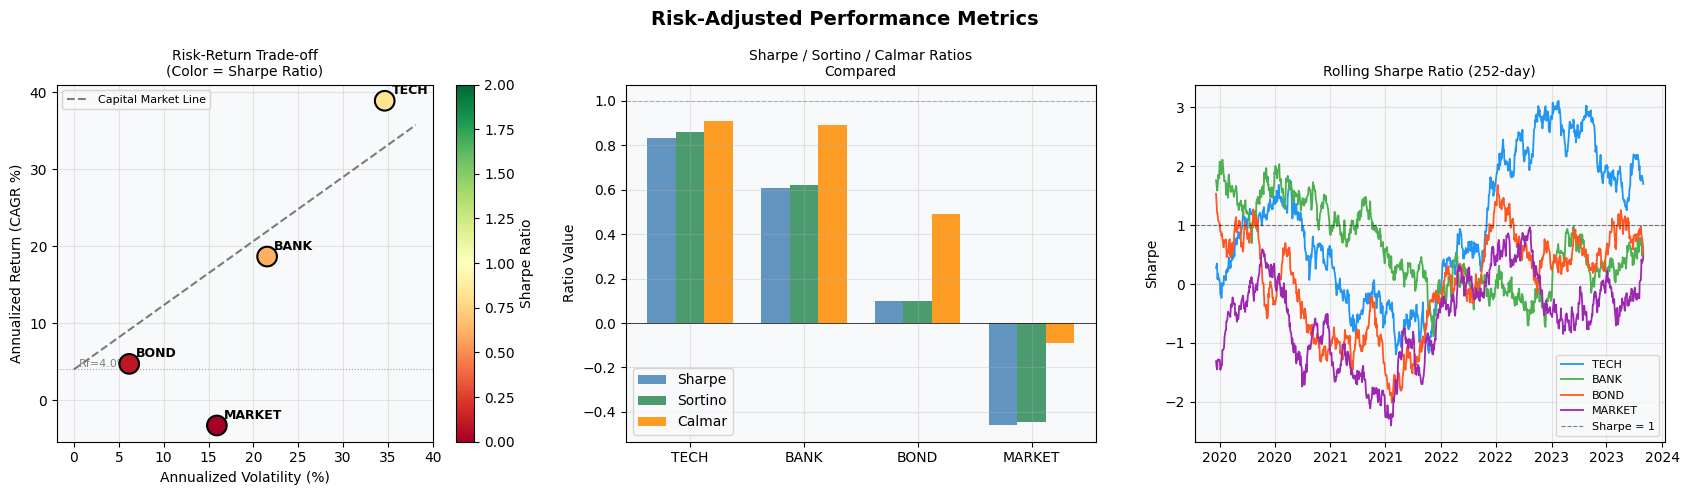

=== Full Performance Summary ===
        CAGR (%)  Ann. Vol (%)  Sharpe  Sortino  Calmar  Max DD (%)
TECH       38.89         34.64   0.833    0.861   0.908      -42.85
BANK       18.66         21.53   0.609    0.619   0.890      -20.95
BOND        4.71          6.16   0.098    0.098   0.491       -9.60
MARKET     -3.29         15.93  -0.461   -0.444  -0.088      -37.37


In [11]:
# ── Risk-Adjusted Performance Metrics ─────────────────────────────────────────
rf_annual = 0.04
rf_daily  = rf_annual / 252

def sharpe(returns, rf=rf_daily):
    excess = returns - rf
    return excess.mean() / returns.std(ddof=1) * np.sqrt(252)

def sortino(returns, rf=rf_daily):
    excess = returns - rf
    downside = returns[returns < rf] - rf
    downside_std = np.sqrt((downside**2).mean()) * np.sqrt(252)
    return excess.mean() * 252 / downside_std if downside_std > 0 else np.nan

def calmar(returns, prices):
    ann_ret = ((prices.iloc[-1] / prices.iloc[0]) ** (252 / len(returns))) - 1
    rolling_max = prices.cummax()
    dd = (prices - rolling_max) / rolling_max
    mdd = abs(dd.min())
    return ann_ret / mdd if mdd > 0 else np.nan

metrics = {}
for name in log_returns.columns:
    r = log_returns[name]
    metrics[name] = {
        'CAGR (%)':        round(cagr[name] * 100, 2),
        'Ann. Vol (%)':    round(annual_std[name] * 100, 2),
        'Sharpe':          round(sharpe(r), 3),
        'Sortino':         round(sortino(r), 3),
        'Calmar':          round(calmar(r, df_prices[name]), 3),
        'Max DD (%)':      round(drawdown_data[name]['max_dd'] * 100, 2),
    }

metrics_df = pd.DataFrame(metrics).T

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Risk-Adjusted Performance Metrics', fontsize=14, fontweight='bold')

asset_names_all = list(log_returns.columns)
asset_colors_list = list(colors_map.values())

# Plot 1: Return vs Vol scatter (the classic risk-return tradeoff)
ann_returns = cagr * 100
ann_vols = annual_std * 100
sharpe_vals = metrics_df['Sharpe']

scatter = axes[0].scatter(ann_vols.values, ann_returns.values,
                          s=200, c=sharpe_vals.values,
                          cmap='RdYlGn', zorder=5,
                          edgecolors='black', linewidths=1.5,
                          vmin=0, vmax=2)
plt.colorbar(scatter, ax=axes[0], label='Sharpe Ratio')
for name, vol, ret in zip(asset_names_all, ann_vols.values, ann_returns.values):
    axes[0].annotate(name, (vol, ret), xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

# Add Capital Market Line (CML)
vols_cml = np.linspace(0, ann_vols.max() * 1.1, 100)
rets_cml = rf_annual * 100 + (sharpe_vals.max()) * vols_cml
axes[0].plot(vols_cml, rets_cml, 'k--', lw=1.5, alpha=0.5, label='Capital Market Line')
axes[0].axhline(rf_annual * 100, color='gray', lw=0.8, linestyle=':', alpha=0.7)
axes[0].text(0.5, rf_annual*100 + 0.3, f'Rf={rf_annual*100:.1f}%', fontsize=8, color='gray')
axes[0].set_xlabel('Annualized Volatility (%)')
axes[0].set_ylabel('Annualized Return (CAGR %)')
axes[0].set_title('Risk-Return Trade-off\n(Color = Sharpe Ratio)', fontsize=10)
axes[0].legend(fontsize=8)

# Plot 2: Metrics bar chart
x = np.arange(len(asset_names_all))
width = 0.25
axes[1].bar(x - width, metrics_df['Sharpe'],   width, label='Sharpe',  color='steelblue', alpha=0.85)
axes[1].bar(x,         metrics_df['Sortino'],  width, label='Sortino', color='seagreen', alpha=0.85)
axes[1].bar(x + width, metrics_df['Calmar'],   width, label='Calmar',  color='darkorange', alpha=0.85)
axes[1].axhline(0, color='black', lw=0.5)
axes[1].axhline(1, color='gray', lw=0.8, linestyle='--', alpha=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(asset_names_all)
axes[1].set_ylabel('Ratio Value')
axes[1].set_title('Sharpe / Sortino / Calmar Ratios\nCompared', fontsize=10)
axes[1].legend()

# Plot 3: Rolling Sharpe (252-day) over time
roll_sharpe = (
    log_returns.rolling(252).mean() - rf_daily
) / log_returns.rolling(252).std(ddof=1) * np.sqrt(252)

for name, color in colors_map.items():
    axes[2].plot(roll_sharpe.index, roll_sharpe[name], label=name, color=color, lw=1.3)
axes[2].axhline(1, color='black', lw=0.8, linestyle='--', alpha=0.5, label='Sharpe = 1')
axes[2].axhline(0, color='gray',  lw=0.5, linestyle=':')
axes[2].set_title('Rolling Sharpe Ratio (252-day)', fontsize=10)
axes[2].set_ylabel('Sharpe')
axes[2].legend(fontsize=8)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

print("=== Full Performance Summary ===")
print(metrics_df.to_string())

## 12. Portfolio Construction — Putting It All Together

Every concept in this notebook feeds directly into building a portfolio. Here we combine **mean, variance, covariance, and correlation** to construct the **Efficient Frontier** — the set of portfolios that maximize return for a given level of risk.

### Markowitz Mean-Variance Optimization
**Minimize portfolio variance** for a target return $\mu^*$:
$$\min_{\mathbf{w}} \; \mathbf{w}^\top \Sigma \mathbf{w} \quad \text{s.t.} \begin{cases} \mathbf{w}^\top \boldsymbol{\mu} = \mu^* \\ \sum_i w_i = 1 \\ w_i \geq 0 \end{cases}$$

Solving for all possible $\mu^*$ traces out the **Efficient Frontier**.

### Three Special Portfolios
| Portfolio | Definition | Use Case |
|-----------|-----------|---------|
| **Minimum Variance** | $\arg\min \sigma_p^2$ | Most defensive, lowest volatility |
| **Maximum Sharpe (Tangency)** | $\arg\max \frac{\mu_p - R_f}{\sigma_p}$ | Optimal for a leveraged investor |
| **Equal Weight** | $w_i = 1/N$ | Simple, robust, hard to beat |

### The Capital Market Line (CML)
Combining the tangency portfolio $T$ with the risk-free asset in proportions $(1-x)$ and $x$:
$$E[R_p] = R_f + \frac{E[R_T] - R_f}{\sigma_T} \cdot \sigma_p$$

This is the highest achievable Sharpe ratio available to any investor — the **CML dominates** the efficient frontier for all investors with access to borrowing/lending at $R_f$.

### Beginner Explanation

Portfolio construction is where the earlier concepts become useful together. Instead of looking at one asset in isolation, we now ask how several assets interact inside one portfolio.

The key beginner idea is: **a portfolio is not just a weighted average of returns, it is also a weighted combination of risks and co-movements.** That is why correlation and covariance matter so much here.

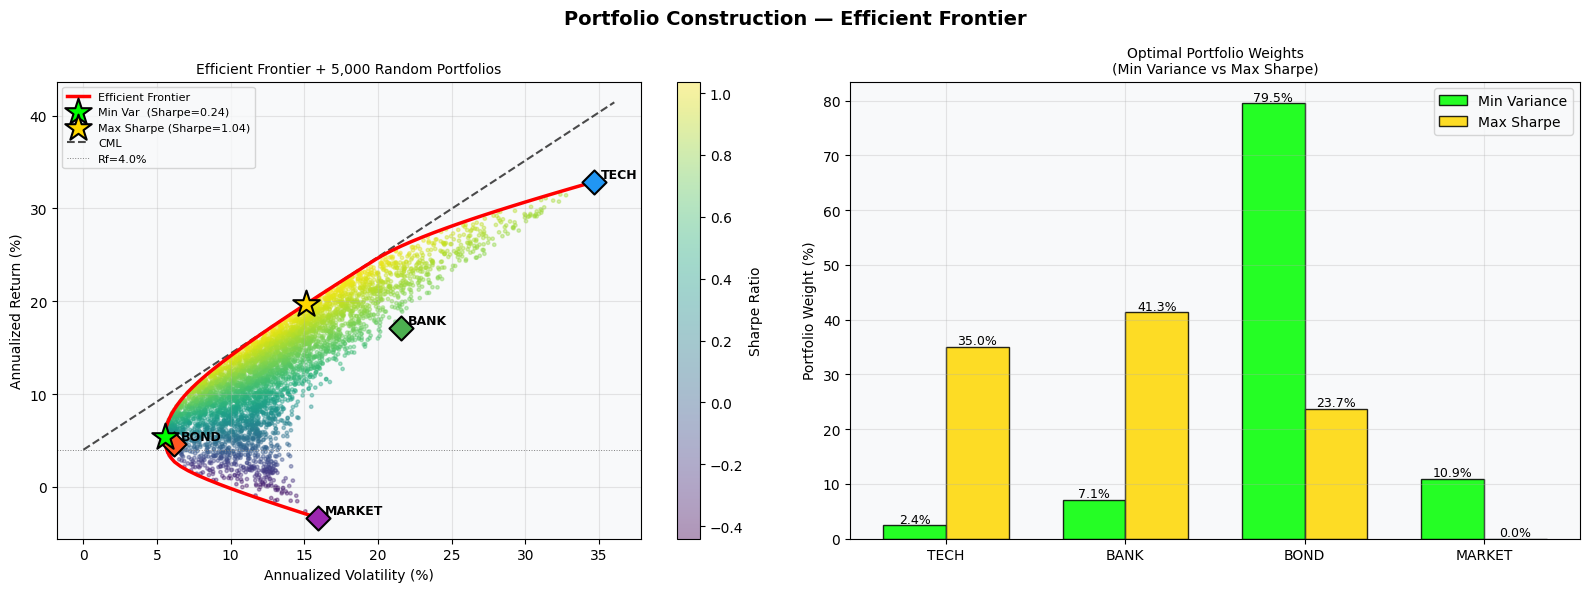

=== Optimization Results ===

Minimum Variance Portfolio:
  TECH: 2.4%
  BANK: 7.1%
  BOND: 79.5%
  MARKET: 10.9%
  → Return=5.32%  Vol=5.53%  Sharpe=0.239

Maximum Sharpe (Tangency) Portfolio:
  TECH: 35.0%
  BANK: 41.3%
  BOND: 23.7%
  MARKET: 0.0%
  → Return=19.66%  Vol=15.08%  Sharpe=1.038


In [12]:
from scipy.optimize import minimize

# ── Inputs for optimization ────────────────────────────────────────────────────
mu_vec   = log_returns.mean().values * 252     # annualized expected returns
Sigma    = cov_matrix.values                   # annualized cov matrix
n        = len(mu_vec)
rf       = rf_annual

# ── Portfolio statistics helper ────────────────────────────────────────────────
def port_stats(w, mu_vec, Sigma, rf):
    ret = w @ mu_vec
    vol = np.sqrt(w @ Sigma @ w)
    sharpe = (ret - rf) / vol
    return ret, vol, sharpe

# ── Monte Carlo random portfolios ─────────────────────────────────────────────
np.random.seed(0)
n_sim = 5000
mc_rets, mc_vols, mc_sharpes, mc_weights = [], [], [], []
for _ in range(n_sim):
    w = np.random.dirichlet(np.ones(n))
    r, v, s = port_stats(w, mu_vec, Sigma, rf)
    mc_rets.append(r)
    mc_vols.append(v)
    mc_sharpes.append(s)
    mc_weights.append(w)

mc_rets    = np.array(mc_rets)
mc_vols    = np.array(mc_vols)
mc_sharpes = np.array(mc_sharpes)

# ── Minimum Variance Portfolio ────────────────────────────────────────────────
def neg_sharpe(w):
    r, v, s = port_stats(w, mu_vec, Sigma, rf)
    return -s

def port_vol(w):
    return np.sqrt(w @ Sigma @ w)

constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
bounds      = [(0, 1)] * n
w0          = np.ones(n) / n

mvp_res = minimize(port_vol, w0, method='SLSQP', bounds=bounds, constraints=constraints)
mvp_w   = mvp_res.x
mvp_ret, mvp_vol, mvp_sharpe = port_stats(mvp_w, mu_vec, Sigma, rf)

# ── Maximum Sharpe (Tangency) Portfolio ────────────────────────────────────────
msr_res = minimize(neg_sharpe, w0, method='SLSQP', bounds=bounds, constraints=constraints)
msr_w   = msr_res.x
msr_ret, msr_vol, msr_sharpe = port_stats(msr_w, mu_vec, Sigma, rf)

# ── Efficient Frontier ─────────────────────────────────────────────────────────
target_rets = np.linspace(mu_vec.min() * 0.9, mu_vec.max() * 1.05, 80)
ef_vols, ef_rets_out = [], []
for target in target_rets:
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'eq', 'fun': lambda w, t=target: w @ mu_vec - t}]
    res = minimize(port_vol, w0, method='SLSQP', bounds=bounds, constraints=cons)
    if res.success:
        ef_vols.append(res.fun)
        ef_rets_out.append(target)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Portfolio Construction — Efficient Frontier', fontsize=14, fontweight='bold')

# Plot 1: Efficient Frontier + MC scatter
sc = axes[0].scatter(mc_vols * 100, mc_rets * 100, c=mc_sharpes,
                     cmap='viridis', s=6, alpha=0.4, zorder=1)
plt.colorbar(sc, ax=axes[0], label='Sharpe Ratio')
axes[0].plot(np.array(ef_vols)*100, np.array(ef_rets_out)*100,
             'r-', lw=2.5, label='Efficient Frontier', zorder=3)

# Individual assets
for name, color in colors_map.items():
    idx = list(log_returns.columns).index(name)
    axes[0].scatter(np.sqrt(Sigma[idx,idx])*100, mu_vec[idx]*100,
                    s=150, color=color, zorder=5, marker='D', edgecolors='black', lw=1.5)
    axes[0].annotate(name, (np.sqrt(Sigma[idx,idx])*100, mu_vec[idx]*100),
                     xytext=(5, 3), textcoords='offset points', fontsize=9, fontweight='bold')

# Special portfolios
axes[0].scatter(mvp_vol*100, mvp_ret*100, marker='*', s=400, color='lime',
                zorder=6, edgecolors='black', lw=1.5, label=f'Min Var  (Sharpe={mvp_sharpe:.2f})')
axes[0].scatter(msr_vol*100, msr_ret*100, marker='*', s=400, color='gold',
                zorder=6, edgecolors='black', lw=1.5, label=f'Max Sharpe (Sharpe={msr_sharpe:.2f})')

# CML
cml_vols = np.linspace(0, max(mc_vols) * 1.1, 100) * 100
cml_rets = rf * 100 + msr_sharpe * cml_vols
axes[0].plot(cml_vols, cml_rets, 'k--', lw=1.5, alpha=0.7, label='CML')
axes[0].axhline(rf * 100, color='gray', lw=0.7, linestyle=':', label=f'Rf={rf*100:.1f}%')

axes[0].set_xlabel('Annualized Volatility (%)')
axes[0].set_ylabel('Annualized Return (%)')
axes[0].set_title('Efficient Frontier + 5,000 Random Portfolios', fontsize=10)
axes[0].legend(fontsize=8)

# Plot 2: Optimal portfolio weights (Min Var vs Max Sharpe)
asset_labels = list(log_returns.columns)
x = np.arange(n)
width = 0.35
axes[1].bar(x - width/2, mvp_w * 100, width, label='Min Variance', color='lime', alpha=0.85, edgecolor='black')
axes[1].bar(x + width/2, msr_w * 100, width, label='Max Sharpe',   color='gold', alpha=0.85, edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(asset_labels)
axes[1].set_ylabel('Portfolio Weight (%)')
axes[1].set_title('Optimal Portfolio Weights\n(Min Variance vs Max Sharpe)', fontsize=10)
axes[1].legend()
for i, (mv, ms) in enumerate(zip(mvp_w, msr_w)):
    axes[1].text(i - width/2, mv*100 + 0.5, f'{mv*100:.1f}%', ha='center', fontsize=9)
    axes[1].text(i + width/2, ms*100 + 0.5, f'{ms*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("=== Optimization Results ===")
print(f"\nMinimum Variance Portfolio:")
for n_name, w in zip(asset_labels, mvp_w):
    print(f"  {n_name}: {w*100:.1f}%")
print(f"  → Return={mvp_ret*100:.2f}%  Vol={mvp_vol*100:.2f}%  Sharpe={mvp_sharpe:.3f}")

print(f"\nMaximum Sharpe (Tangency) Portfolio:")
for n_name, w in zip(asset_labels, msr_w):
    print(f"  {n_name}: {w*100:.1f}%")
print(f"  → Return={msr_ret*100:.2f}%  Vol={msr_vol*100:.2f}%  Sharpe={msr_sharpe:.3f}")

## 13. Stationarity — Why We Model Returns, Not Prices

**Stationarity** is the most fundamental requirement in time series analysis. A **stationary** series has:

| Property | Requirement | Why It Matters |
|----------|-------------|----------------|
| **Constant mean** | $E[r_t] = \mu$ for all $t$ | Regression coefficients are stable over time |
| **Constant variance** | $\text{Var}(r_t) = \sigma^2$ for all $t$ | Standard errors and confidence intervals are valid |
| **Covariance by lag only** | $\text{Cov}(r_t, r_{t-k})$ depends only on $k$, not $t$ | ACF/PACF and ARIMA models are meaningful |

Without stationarity, virtually every statistical tool gives misleading results.

### Why Stock Prices Are Non-Stationary
A price series drifts upward over time — its **mean is not constant**. Two random walks can appear highly correlated even with no causal link (**spurious regression**). The risk of incorrect conclusions is severe.

$$\underbrace{P_t}_{\text{I(1) — non-stationary}} \xrightarrow{\;\Delta\text{ (difference)}\;} \underbrace{r_t = \ln(P_t/P_{t-1})}_{\text{I(0) — stationary}}$$

### Integration Order
- **I(0)**: Already stationary. No differencing needed. → *Log returns*
- **I(1)**: One round of differencing makes it stationary. → *Log price levels*
- **I(2)**: Two rounds needed. → *Rare in finance; nominal prices in hyperinflation*

### Tests for Stationarity

**Augmented Dickey-Fuller (ADF)** — tests for a unit root:
$$H_0:\text{ unit root present (non-stationary)} \quad H_1:\text{ stationary}$$
$$\Delta r_t = \alpha + \beta t + \gamma r_{t-1} + \sum_{j=1}^{p}\delta_j \Delta r_{t-j} + \varepsilon_t$$
Test stat on $\gamma$: small (negative) $\Rightarrow$ reject $H_0$ $\Rightarrow$ **stationary**. Low $p$-value is good.

**KPSS** — tests the *null of stationarity* (the reverse):
$$H_0:\text{ stationary} \quad H_1:\text{ unit root}$$
High $p$-value: fail to reject $H_0$ → **stationary**. Low $p$-value: reject → non-stationary.

Use both together to reduce false positives:

| ADF p | KPSS p | Conclusion |
|-------|--------|-----------|
| > 0.05 | < 0.05 | ❌ Non-stationary (both agree) |
| < 0.05 | > 0.05 | ✅ Stationary (both agree) |
| < 0.05 | < 0.05 | Mixed — check for structural breaks |
| > 0.05 | > 0.05 | Mixed — likely near unit root |

### Practical Consequences
- **Never regress price on price** — always use returns.
- **ARIMA model order** is based on how many differences are needed to reach stationarity.
- **Cointegration** is the exception: two non-stationary price series with a *stationary spread* can be traded (pairs trading). The Engle-Granger test checks whether $P_{i,t} - \alpha P_{j,t}$ is I(0).
- **Risk models** (VaR, covariance matrices) must be estimated on returns, not prices.


### Beginner Explanation

Stationarity means the statistical behavior of a series is stable enough to model. If the mean and variance keep drifting, many time-series tools stop being reliable.

This is why quants usually model **returns** instead of **prices**: prices tend to wander and trend, while returns are often much closer to stationary.

=== Stationarity Tests: ADF & KPSS ===
ADF  H₀ = unit root   → p < 0.05 ⟹ STATIONARY  (reject unit root)
KPSS H₀ = stationary  → p > 0.05 ⟹ STATIONARY  (fail to reject stationarity)

Asset    Series           ADF stat    ADF p   KPSS stat   KPSS p          Verdict
─────────────────────────────────────────────────────────────────────────────────
TECH     Price               1.808   0.9984       4.088   0.0100 ❌ NON-STATIONARY
TECH     Log Return        -36.452   0.0000       0.342   0.1000     ✅ STATIONARY
BANK     Price              -1.433   0.5664       4.854   0.0100 ❌ NON-STATIONARY
BANK     Log Return        -19.362   0.0000       0.153   0.1000     ✅ STATIONARY
BOND     Price              -1.122   0.7063       4.152   0.0100 ❌ NON-STATIONARY
BOND     Log Return        -36.390   0.0000       0.072   0.1000     ✅ STATIONARY
MARKET   Price              -2.646   0.0838       3.697   0.0100 ❌ NON-STATIONARY
MARKET   Log Return        -35.851   0.0000       0.296   0.1000     ✅ STATIONA

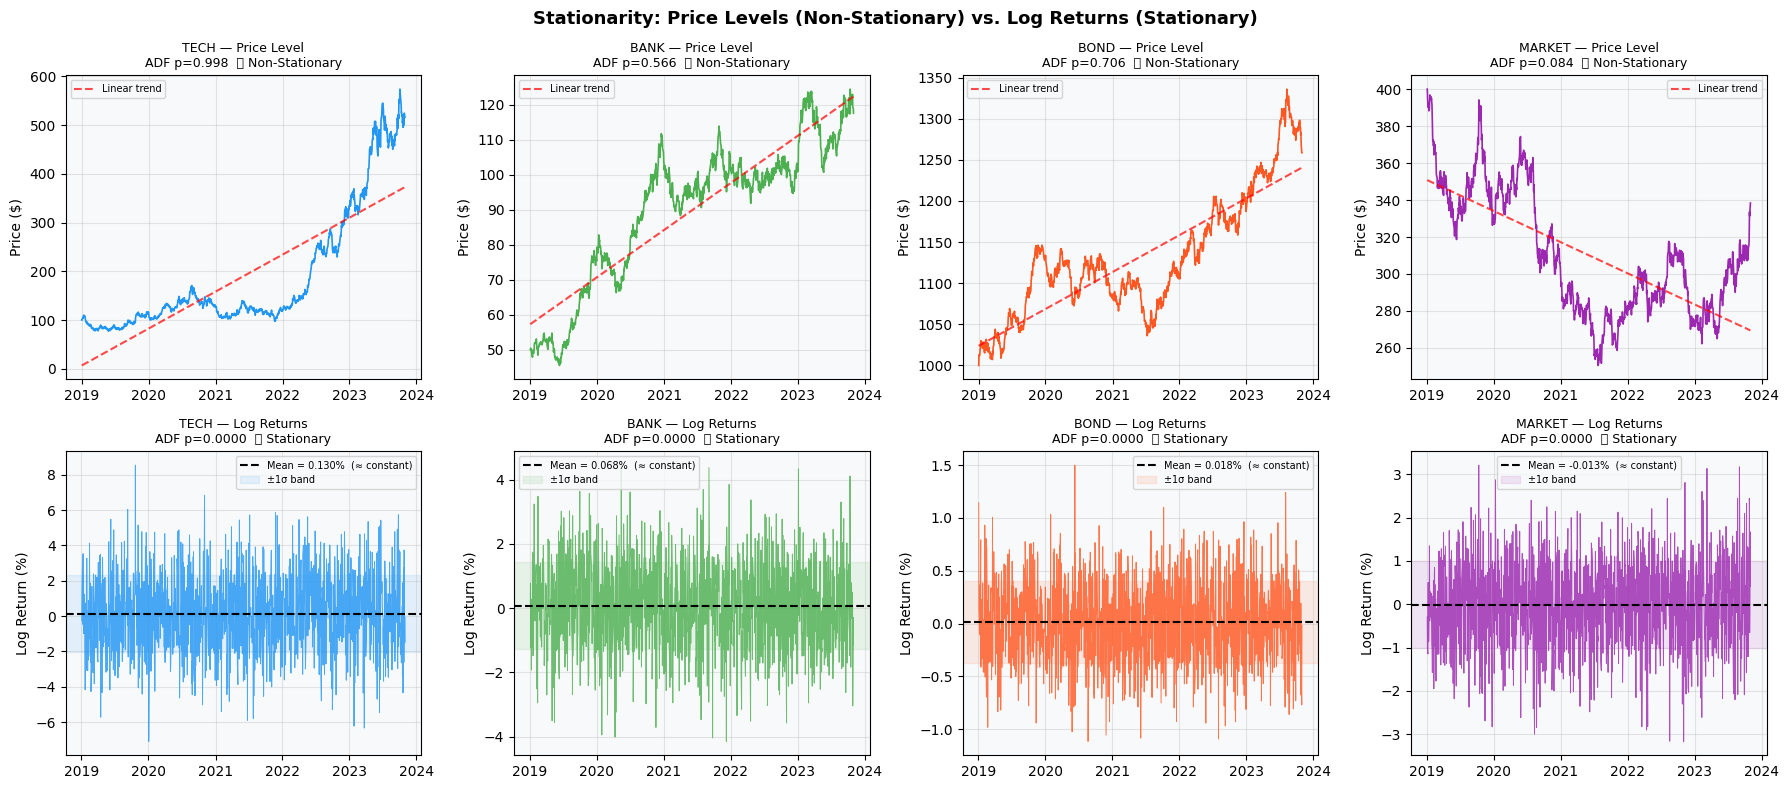


=== Summary ===
Prices  : ADF fails to reject H₀ → trend present → NON-STATIONARY  (I(1) process)
Returns : ADF rejects H₀         → no trend → STATIONARY           (I(0) process)

Golden rule: ALWAYS model log returns, never raw prices!
Exception:   Two I(1) price series can be COINTEGRATED → pairs trading if the
             price SPREAD is I(0). Test with Engle-Granger or Johansen cointegration tests.


In [13]:
import warnings
from statsmodels.tsa.stattools import adfuller, kpss as kpss_test_fn

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore')   # suppress KPSS InterpolationWarning

# ── Helper functions ──────────────────────────────────────────────────────────
def run_adf(series):
    """ADF: H₀ = unit root (non-stationary). Low p → stationary."""
    res = adfuller(series.dropna(), autolag='AIC')
    return res[0], res[1], res[1] < 0.05

def run_kpss(series):
    """KPSS: H₀ = stationary. Low p → non-stationary (opposite of ADF)."""
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        res = kpss_test_fn(series.dropna(), regression='c', nlags='auto')
    return res[0], res[1], res[1] > 0.05   # True = stationary

# ── Run tests on prices and log-returns for all assets ────────────────────────
print("=== Stationarity Tests: ADF & KPSS ===")
print("ADF  H₀ = unit root   → p < 0.05 ⟹ STATIONARY  (reject unit root)")
print("KPSS H₀ = stationary  → p > 0.05 ⟹ STATIONARY  (fail to reject stationarity)\n")

header = f"{'Asset':<8} {'Series':<14} {'ADF stat':>10} {'ADF p':>8} {'KPSS stat':>11} {'KPSS p':>8} {'Verdict':>16}"
print(header)
print('─' * len(header))

stat_results = {}
for name in df_prices.columns:
    for label, series in [('Price', df_prices[name]), ('Log Return', log_returns[name])]:
        adf_s, adf_p, adf_stat = run_adf(series)
        kpss_s, kpss_p, kpss_stat = run_kpss(series)
        both_agree_stationary = adf_stat and kpss_stat
        verdict = '✅ STATIONARY' if both_agree_stationary else '❌ NON-STATIONARY'
        print(f"{name:<8} {label:<14} {adf_s:>10.3f} {adf_p:>8.4f} {kpss_s:>11.3f} {kpss_p:>8.4f} {verdict:>16}")
        stat_results[(name, label)] = (adf_p, kpss_p, both_agree_stationary)

# ── Visual: prices vs log returns, 2 rows × 4 cols ────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle(
    'Stationarity: Price Levels (Non-Stationary) vs. Log Returns (Stationary)',
    fontsize=13, fontweight='bold'
)

for col, (name, color) in enumerate(colors_map.items()):
    # ─ Row 0: Price level
    ax_p = axes[0, col]
    ax_p.plot(df_prices.index, df_prices[name], color=color, lw=1.2)
    # Overlay linear trend to show non-stationarity (changing mean)
    t_arr = np.arange(len(df_prices[name]))
    z_t = np.polyfit(t_arr, df_prices[name].values, 1)
    ax_p.plot(df_prices.index, np.poly1d(z_t)(t_arr),
              'r--', lw=1.5, alpha=0.7, label='Linear trend')
    adf_p_price = stat_results[(name, 'Price')][0]
    ax_p.set_title(
        f'{name} — Price Level\nADF p={adf_p_price:.3f}  ❌ Non-Stationary',
        fontsize=9
    )
    ax_p.set_ylabel('Price ($)')
    ax_p.legend(fontsize=7)
    ax_p.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # ─ Row 1: Log returns
    ax_r = axes[1, col]
    ret = log_returns[name]
    ax_r.plot(ret.index, ret * 100, color=color, lw=0.7, alpha=0.8)
    ax_r.axhline(ret.mean() * 100, color='black', lw=1.5, linestyle='--',
                 label=f'Mean = {ret.mean()*100:.3f}%  (≈ constant)')
    # Shade ±1σ band to show constant variance
    ax_r.axhspan(
        (ret.mean() - ret.std()) * 100, (ret.mean() + ret.std()) * 100,
        alpha=0.1, color=color, label='±1σ band'
    )
    adf_p_ret = stat_results[(name, 'Log Return')][0]
    ax_r.set_title(
        f'{name} — Log Returns\nADF p={adf_p_ret:.4f}  ✅ Stationary',
        fontsize=9
    )
    ax_r.set_ylabel('Log Return (%)')
    ax_r.legend(fontsize=7)
    ax_r.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

print("\n=== Summary ===")
print("Prices  : ADF fails to reject H₀ → trend present → NON-STATIONARY  (I(1) process)")
print("Returns : ADF rejects H₀         → no trend → STATIONARY           (I(0) process)")
print("\nGolden rule: ALWAYS model log returns, never raw prices!")
print("Exception:   Two I(1) price series can be COINTEGRATED → pairs trading if the")
print("             price SPREAD is I(0). Test with Engle-Granger or Johansen cointegration tests.")


## 14. Autocorrelation — Are Returns Predictable?

**Autocorrelation** (serial correlation) measures whether knowing today's return helps predict tomorrow's. If autocorrelation exists, the market has exploitable patterns — this directly contradicts the **Efficient Market Hypothesis (EMH)**.

### ACF — Autocorrelation Function
$$\text{ACF}(k) = \rho_k = \frac{\text{Cov}(r_t,\; r_{t-k})}{\text{Var}(r_t)}$$

The ACF at lag $k$ is the correlation between a return and the same return $k$ days later. A spike at lag 1 would mean "yesterday's return predicts today's return."

**How to read an ACF plot**:  
- Each bar is the correlation at that lag.  
- The **blue shaded band** is the 95% confidence interval under the null of zero autocorrelation.  
- Bars outside the band → statistically significant autocorrelation at that lag.  
- For returns in an efficient market, **all bars should lie within the band**.

### PACF — Partial Autocorrelation Function
The PACF at lag $k$ measures the *direct* effect of the $k$-day-ago return on today's return, after removing the influence of lags 1 through $k-1$. Used to identify the order $p$ of an AR model: cut-off at lag $p$ in the PACF → AR($p$) model.

### Ljung-Box Test — Formal Test for Serial Correlation
Jointly tests whether the first $m$ autocorrelations are all zero:
$$H_0: \rho_1 = \rho_2 = \cdots = \rho_m = 0 \quad \text{(white noise)}$$
$$Q = T(T+2)\sum_{k=1}^{m}\frac{\hat{\rho}_k^2}{T-k} \;\sim\; \chi^2(m)$$

A low $p$-value rejects the white-noise null — autocorrelation is present.

### The Two Central Results in Empirical Finance

| Series | Typical ACF | Ljung-Box | Interpretation |
|--------|------------|-----------|----------------|
| **Raw returns** $r_t$ | No significant spikes | $p > 0.05$ ✅ | Returns are approximately unpredictable (EMH holds) |
| **Squared returns** $r_t^2$ | Strong, slowly decaying spikes | $p \ll 0.05$ 🔴 | **Volatility clusters** — large moves follow large moves |
| **Absolute returns** $\|r_t\|$ | Very persistent, slow decay | $p \ll 0.05$ 🔴 | Long memory in volatility magnitude |

### Why This Matters for Strategy Design

| Finding | Implication |
|---------|-------------|
| No ACF in raw returns | Simple momentum on daily returns does not work; look at weekly/monthly |
| Strong ACF in $r^2$ | Tomorrow's volatility is forecastable → use **GARCH** for risk management and options pricing |
| Negative lag-1 ACF | Bid-ask bounce effect (microstructure noise) — common in tick data |
| Positive lag-1 ACF | Short-term momentum; common in thin markets or high-frequency data |

### Beginner Checklist
- ✅ Always plot ACF of **both** returns **and** squared returns before modelling
- ✅ If $r^2$ ACF has many spikes: use GARCH(1,1) instead of constant-vol assumption
- ✅ If raw return ACF has spikes: there may be a linear predictability opportunity (or a data error)
- ✅ Ljung-Box $p$-value is a quick, single-number summary of the full ACF pattern


### Beginner Explanation

Autocorrelation checks whether the past helps predict the future. If returns have meaningful autocorrelation, there may be a pattern to exploit.

In practice, raw daily returns often show little predictability, but volatility often does. That is why many models forecast **how large moves may be**, even when they cannot forecast the exact direction.

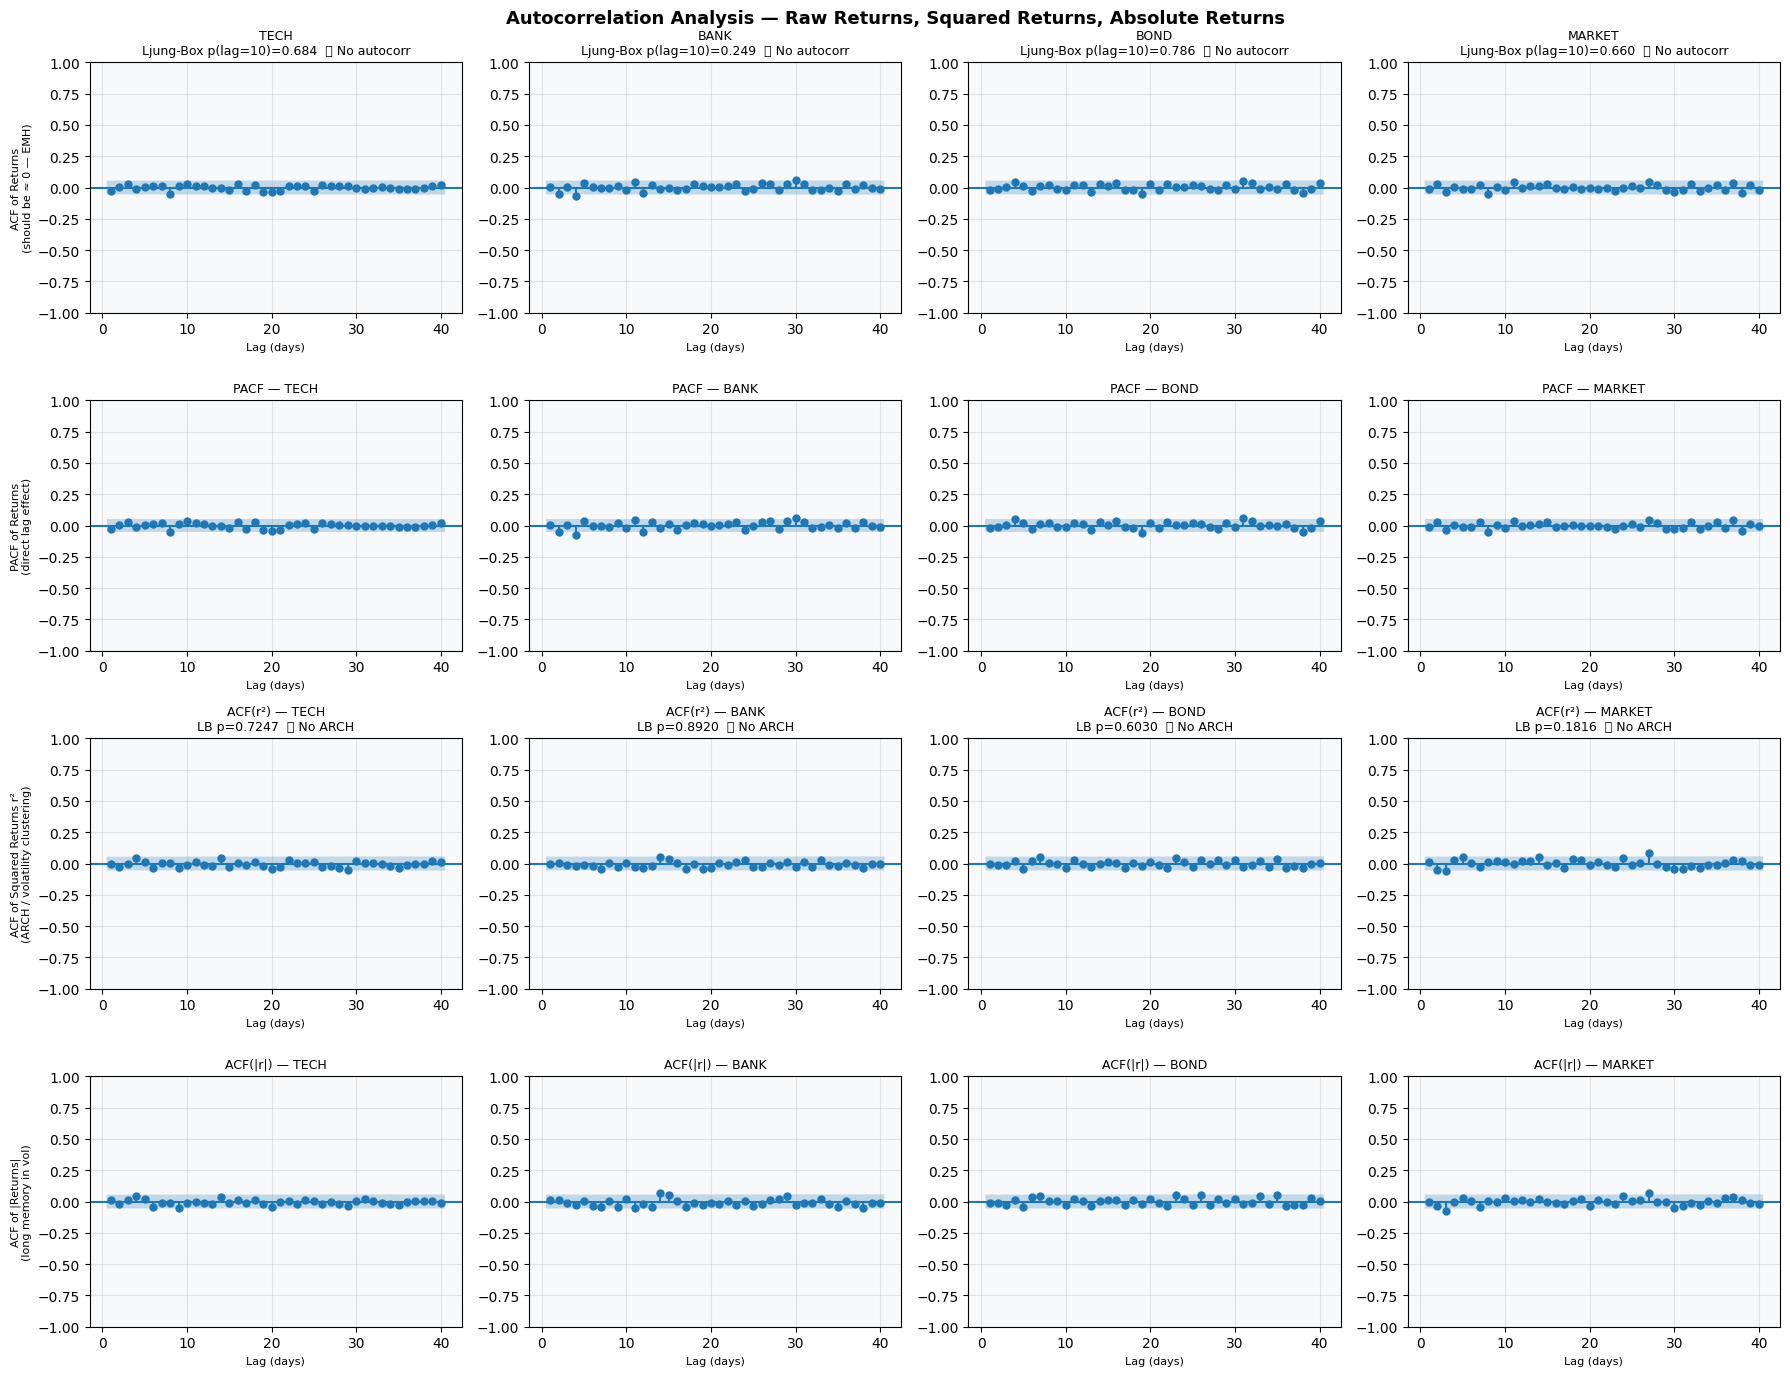

=== Ljung-Box Serial Correlation Test (lag = 10) ===
H₀: No autocorrelation  |  p < 0.05 → autocorrelation present

Asset     Series                 LB Stat    p-value                 Finding
───────────────────────────────────────────────────────────────────────────
  TECH    Returns r                 7.43     0.6844       🟢 i.i.d. (random)
  TECH    Squared  r²               7.01     0.7247       🟢 i.i.d. (random)
  TECH    Absolute |r|              9.51     0.4842       🟢 i.i.d. (random)

  BANK    Returns r                12.57     0.2489       🟢 i.i.d. (random)
  BANK    Squared  r²               4.99     0.8920       🟢 i.i.d. (random)
  BANK    Absolute |r|              8.84     0.5469       🟢 i.i.d. (random)

  BOND    Returns r                 6.34     0.7858       🟢 i.i.d. (random)
  BOND    Squared  r²               8.26     0.6030       🟢 i.i.d. (random)
  BOND    Absolute |r|              8.50     0.5802       🟢 i.i.d. (random)

  MARKET  Returns r                 7.69     

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

n_lags_show = 40   # number of lags to display in ACF/PACF plots

# ── 4×4 ACF/PACF chart ────────────────────────────────────────────────────────
# Rows: ACF(r) | PACF(r) | ACF(r²) | ACF(|r|)
# Cols: one per asset (TECH, BANK, BOND, MARKET)
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
fig.suptitle('Autocorrelation Analysis — Raw Returns, Squared Returns, Absolute Returns',
             fontsize=13, fontweight='bold')

row_labels = [
    'ACF of Returns\n(should be ≈ 0 — EMH)',
    'PACF of Returns\n(direct lag effect)',
    'ACF of Squared Returns r²\n(ARCH / volatility clustering)',
    'ACF of |Returns|\n(long memory in vol)',
]

for col, name in enumerate(log_returns.columns):
    r = log_returns[name]

    # Row 0: ACF of raw returns
    plot_acf(r, lags=n_lags_show, ax=axes[0, col], alpha=0.05, zero=False)
    lb_p = acorr_ljungbox(r, lags=[10], return_df=True)['lb_pvalue'].values[0]
    axes[0, col].set_title(
        f'{name}\nLjung-Box p(lag=10)={lb_p:.3f}  '
        f'{"✅ No autocorr" if lb_p > 0.05 else "⚠️ Autocorr"}',
        fontsize=9
    )
    axes[0, col].set_xlabel('Lag (days)', fontsize=8)

    # Row 1: PACF of raw returns (direct partial autocorrelation)
    plot_pacf(r, lags=n_lags_show, ax=axes[1, col], alpha=0.05, zero=False, method='ywm')
    axes[1, col].set_title(f'PACF — {name}', fontsize=9)
    axes[1, col].set_xlabel('Lag (days)', fontsize=8)

    # Row 2: ACF of squared returns (test for ARCH / volatility clustering)
    r_sq = r ** 2
    plot_acf(r_sq, lags=n_lags_show, ax=axes[2, col], alpha=0.05, zero=False)
    lb_sq = acorr_ljungbox(r_sq, lags=[10], return_df=True)['lb_pvalue'].values[0]
    axes[2, col].set_title(
        f'ACF(r²) — {name}\nLB p={lb_sq:.4f}  '
        f'{"⚠️ ARCH effects!" if lb_sq < 0.05 else "✅ No ARCH"}',
        fontsize=9
    )
    axes[2, col].set_xlabel('Lag (days)', fontsize=8)

    # Row 3: ACF of absolute returns (long-memory proxy)
    plot_acf(r.abs(), lags=n_lags_show, ax=axes[3, col], alpha=0.05, zero=False)
    axes[3, col].set_title(f'ACF(|r|) — {name}', fontsize=9)
    axes[3, col].set_xlabel('Lag (days)', fontsize=8)

# Row y-labels
for row, rl in enumerate(row_labels):
    axes[row, 0].set_ylabel(rl, fontsize=8, labelpad=4)

plt.tight_layout()
plt.show()

# ── Ljung-Box summary table ────────────────────────────────────────────────────
print("=== Ljung-Box Serial Correlation Test (lag = 10) ===")
print("H₀: No autocorrelation  |  p < 0.05 → autocorrelation present\n")

header = f"{'Asset':<8}  {'Series':<18}  {'LB Stat':>10}  {'p-value':>9}  {'Finding':>22}"
print(header)
print('─' * len(header))

for name in log_returns.columns:
    r = log_returns[name]
    for label, series in [
        ('Returns r',       r),
        ('Squared  r²',     r ** 2),
        ('Absolute |r|',    r.abs()),
    ]:
        lb  = acorr_ljungbox(series, lags=[10], return_df=True)
        st  = lb['lb_stat'].values[0]
        pv  = lb['lb_pvalue'].values[0]
        tag = '🔴 Autocorrelated' if pv < 0.05 else '🟢 i.i.d. (random)'
        print(f"  {name:<6}  {label:<18}  {st:>10.2f}  {pv:>9.4f}  {tag:>22}")
    print()

print("─" * 70)
print("Interpretation:")
print("  • Returns r  → mostly 🟢: returns are unpredictable short-term (EMH holds)")
print("  • Squared r² → mostly 🔴: VOLATILITY is persistent — large moves cluster together")
print("  • |Returns|  → mostly 🔴: long-memory in vol magnitude (supports GARCH family models)")
print("\nBottom line: you cannot easily predict the DIRECTION of tomorrow's return,")
print("but you CAN predict whether tomorrow will be a high- or low-volatility day.")


## 15. Simulating Different Market Scenarios

Real markets are not a single fixed process. Recognising **which kind of process** generated the price series you are looking at determines what tools, models, and strategies are appropriate.

### Four Fundamental Processes

| Scenario | Process | Typical Real-World Asset | Key Characteristic |
|----------|---------|-------------------------|--------------------|
| **Bull Market** | GBM (high drift) | Growth stocks, equity indices in expansion | Price trends up, returns near-normal |
| **Jump Diffusion** | GBM + Poisson jumps | Any equity during crises, crypto | Sudden large negative moves; fat left tail |
| **Mean-Reverting** | Ornstein-Uhlenbeck (OU) | Credit spreads, FX rates, vol index, pairs spread | Price oscillates around a fixed level |
| **Regime-Switching** | Two-state Markov GBM | Equity indices (bull vs. bear cycle) | Volatility explosions at state transitions |

---

### Ornstein-Uhlenbeck (Mean-Reverting) Process
$$dX_t = \kappa(\theta - X_t)\,dt + \sigma\,dW_t$$

| Parameter | Symbol | Meaning |
|-----------|--------|---------|
| Speed of reversion | $\kappa$ | How quickly it snaps back to the mean. **Half-life** $= \ln(2)/\kappa$ |
| Long-run mean | $\theta$ | The level the process reverts to |
| Diffusion | $\sigma$ | Magnitude of random shocks |

A higher $\kappa$ means faster reversion (half-life shrinks). A spread with $\kappa = 3$ reverts halfway to the mean in about 59 trading days.

**Why OU matters**: The spread between two cointegrated stocks is modelled as OU — this is the mathematical foundation of **pairs trading**. The Vasicek interest-rate model is also OU.

---

### Jump Diffusion (Merton Model)
$$\frac{dS}{S} = \mu\,dt + \sigma\,dW_t + dJ_t$$

where $J_t$ is a compound Poisson process: jumps arrive at rate $\lambda$ per year; each jump size $J \sim \mathcal{N}(\mu_J, \sigma_J^2)$.

A **negative** mean jump size ($\mu_J < 0$) produces the **left-skewed** distribution and **fat left tail** observed in real equity returns. The Black-Scholes model (pure GBM) cannot produce this skew — it is one reason the volatility smile exists.

---

### How to Identify the Regime You Are In

| Signal | Bull GBM | Jump Diffusion | Mean-Reverting | Regime-Switch |
|--------|----------|----------------|---------------|---------------|
| Price trend | Up, smooth | Up then sudden drops | Oscillating | Step-changes |
| Return distribution | ≈ Normal | Negative skew, fat left tail | ≈ Symmetric, compact | Heavy tails at switches |
| Rolling vol | Stable | Spike on jump days | Stable/low | Jumps at transitions |
| Vol Ratio (VR) | ≈ 1 | Spike > 2 on jumps | Stable | Spikes at regime changes |
| Z-scores | Within ±2 | Occasional |z| > 5 | Bounded ±3 | Clustered extremes |


### Beginner Explanation

Not every market behaves the same way all the time. Some assets trend smoothly, some jump suddenly, some revert toward a fair value, and some switch between calm and crisis states.

This section is useful because model choice should follow the data-generating process. A mean-reverting spread and a crash-prone equity index should not be treated as if they come from the same kind of world.

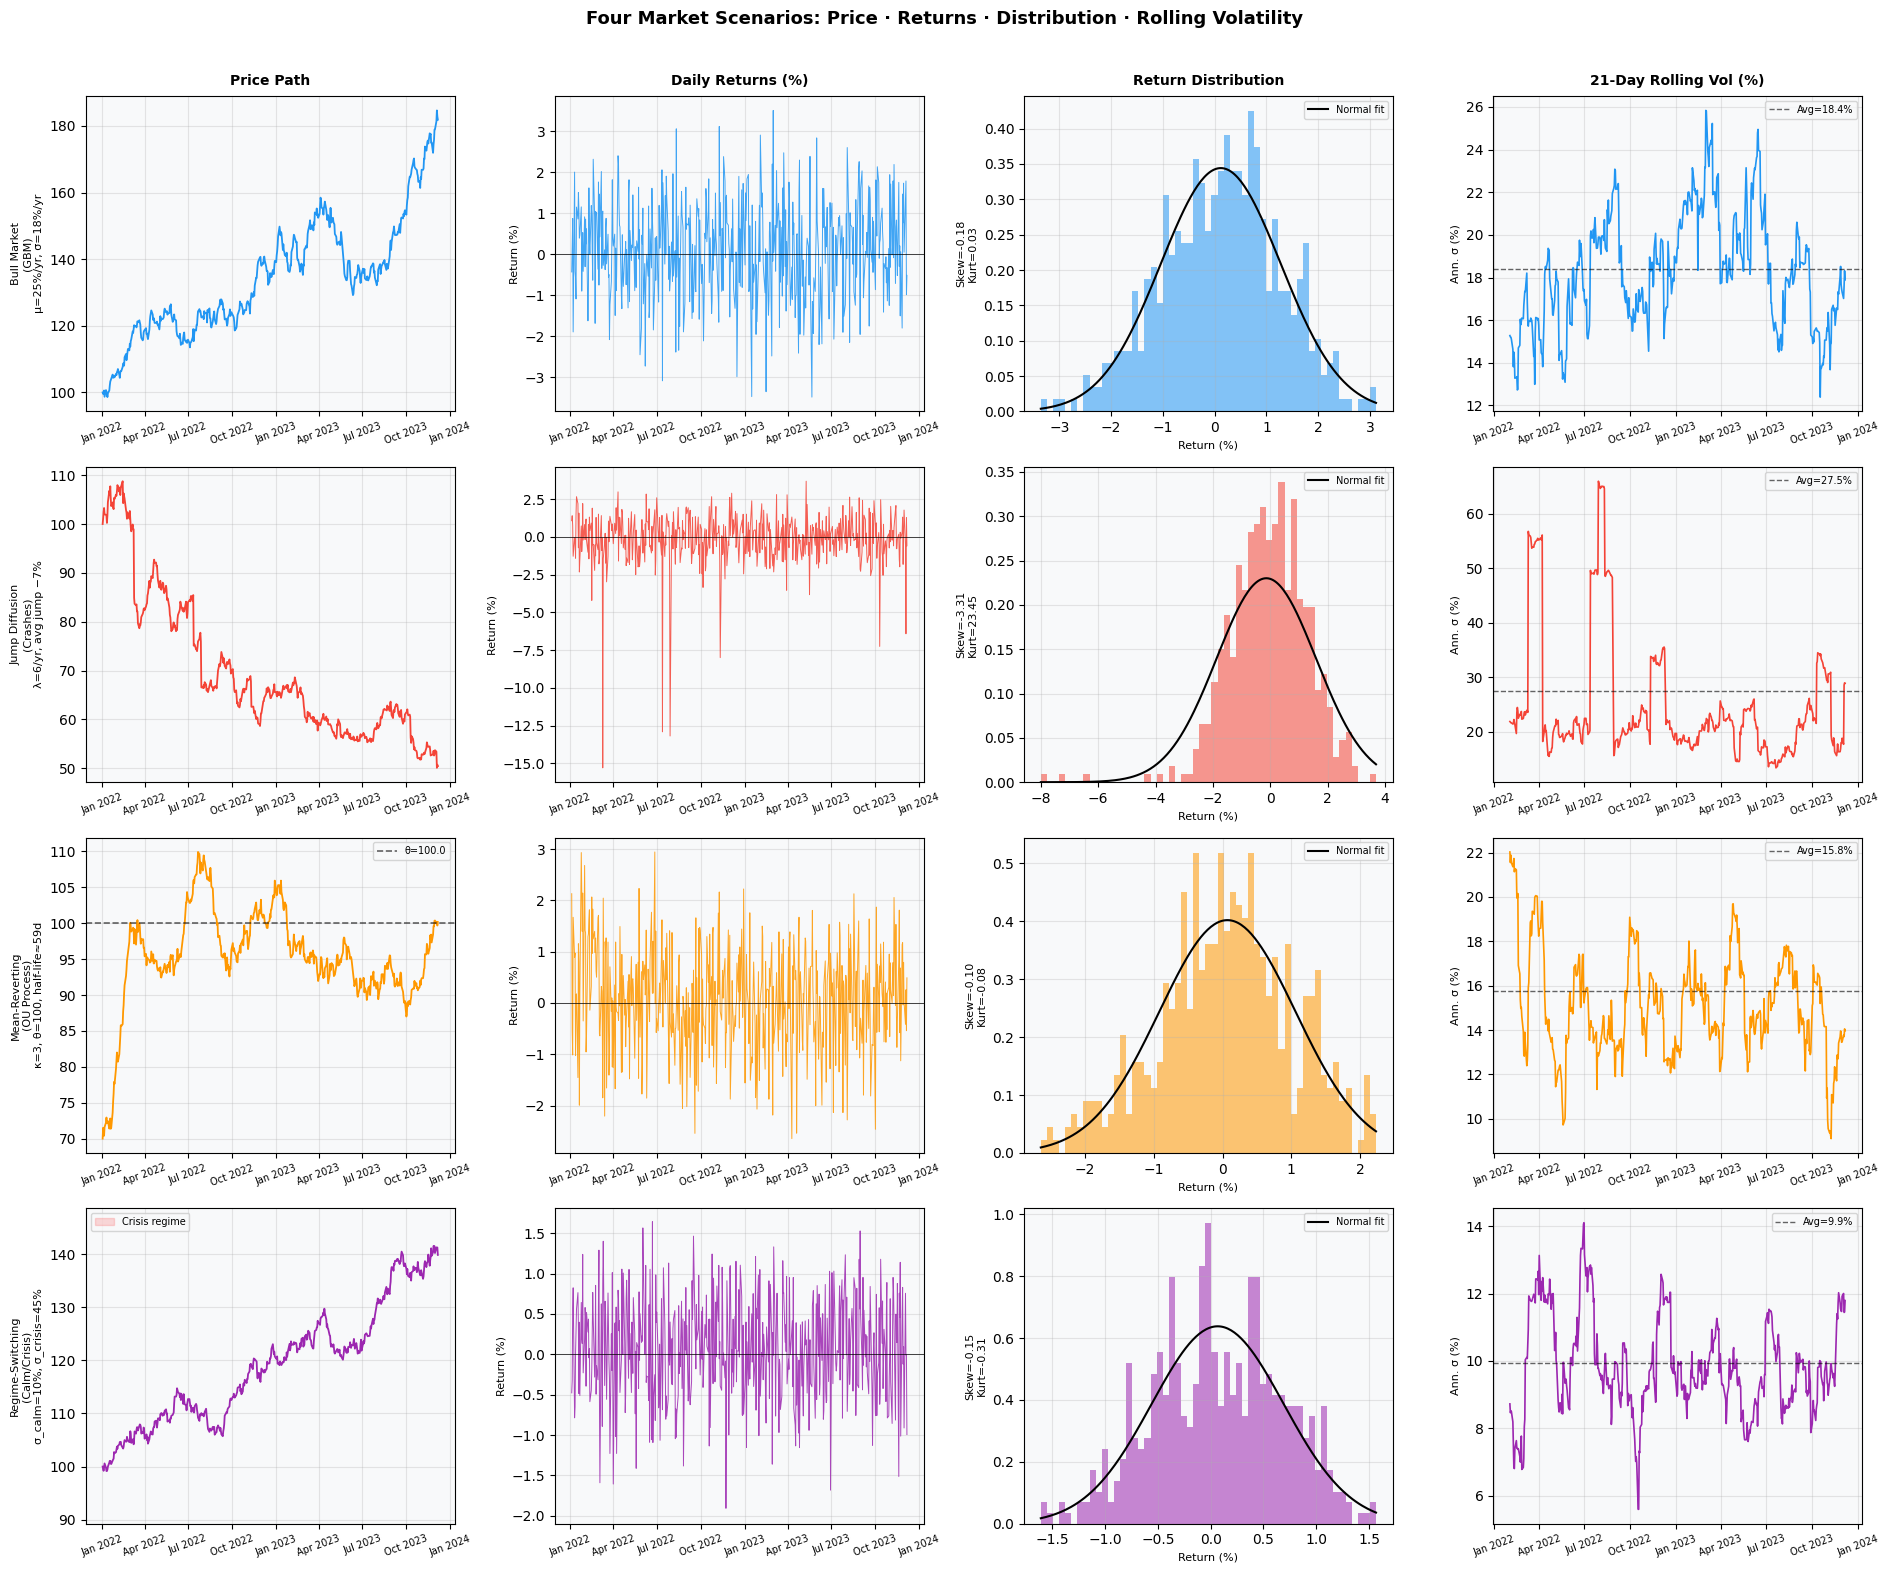

=== Scenario Comparison Statistics ===
Scenario                        CAGR%   Ann.σ%   Skewness   Ex.Kurt   Min ret%   Max ret%
─────────────────────────────────────────────────────────────────────────────────────────
  Bull Market (GBM)             34.94    18.42     -0.183     0.033     -3.490      3.508
  Jump Diffusion (Crashes)     -29.02    27.55     -3.311    23.455    -15.303      3.688
  Mean-Reverting (OU Process)    19.67    15.77     -0.096    -0.076     -2.645      2.945
  Regime-Switching (Calm/Crisis)    18.30     9.93     -0.151    -0.313     -1.908      1.643

Key takeaways per scenario:
  Bull Market  : returns near-normal, stable upward trending price, low vol
  Jump Diffusion: negative skew + fat left tail from crashes — normal fit misses the tail
  Mean-Reverting: price stays near θ=100; use OU for credit spreads, FX, pairs trading
  Regime-Switch : clustered vol — long calm stretches then sudden vol explosions


In [16]:
# ── Four market scenario simulations ─────────────────────────────────────────
n_s    = 504          # 2 years of trading days
dt_s   = 1 / 252
dates_s = pd.bdate_range('2022-01-03', periods=n_s)
RNG_s  = np.random.default_rng(99)

# ─── Scenario 1: Bull Market (GBM, strong drift) ─────────────────────────────
mu_b, sig_b = 0.25, 0.18
Z1 = RNG_s.standard_normal(n_s)
dr_bull      = np.exp((mu_b - 0.5*sig_b**2)*dt_s + sig_b*np.sqrt(dt_s)*Z1)
dr_bull[0]   = 1.0
p_bull       = 100.0 * dr_bull.cumprod()

# ─── Scenario 2: Jump Diffusion (GBM + random crash events) ──────────────────
# Each day a Poisson number of jumps arrive; each jump shrinks the price on avg -7%
mu_jd, sig_jd       = 0.08, 0.20
lam, mu_j, sig_j    = 6.0, -0.07, 0.04    # 6 jumps/yr; avg size −7%
Z2      = RNG_s.standard_normal(n_s)
n_jumps = RNG_s.poisson(lam * dt_s, n_s)  # number of jumps each day
j_sizes = RNG_s.normal(mu_j, sig_j, n_s) * n_jumps
dr_jd   = np.exp((mu_jd - 0.5*sig_jd**2)*dt_s + sig_jd*np.sqrt(dt_s)*Z2 + j_sizes)
dr_jd[0] = 1.0
p_jd    = 100.0 * dr_jd.cumprod()

# ─── Scenario 3: Mean-Reverting (Ornstein-Uhlenbeck) ─────────────────────────
# Used for credit spreads, FX rates, Vol indices, pairs-trading spreads
# dX = κ(θ − X)dt + σ dW      half-life = ln(2)/κ ≈ 59 days for κ=3
kappa_ou, theta_ou, sig_ou = 3.0, 100.0, 15.0
X_ou     = np.zeros(n_s)
X_ou[0]  = 70.0     # start well below long-run mean to show reversion clearly
Z3 = RNG_s.standard_normal(n_s)
for t in range(1, n_s):
    X_ou[t] = (X_ou[t-1]
               + kappa_ou * (theta_ou - X_ou[t-1]) * dt_s
               + sig_ou * np.sqrt(dt_s) * Z3[t])
p_ou = np.maximum(X_ou, 0.5)   # keep positive

# ─── Scenario 4: Regime-Switching ────────────────────────────────────────────
# Two Markov states: calm (low vol) and turbulent (crisis). State persists
# then flips randomly. Average ~2 yr calm, ~4 months turbulent.
mu_lo, sig_lo = 0.12, 0.10
mu_hi, sig_hi = -0.10, 0.45
p_calm2turb   = 1 / (252 * 2.0)   # daily prob of leaving calm
p_turb2calm   = 1 / (252 * 0.33)  # daily prob of leaving turbulent
regime_rs = np.zeros(n_s, dtype=int)
for t in range(1, n_s):
    flip_prob = p_calm2turb if regime_rs[t-1] == 0 else p_turb2calm
    regime_rs[t] = 1 - regime_rs[t-1] if RNG_s.random() < flip_prob else regime_rs[t-1]
Z4    = RNG_s.standard_normal(n_s)
dr_rs = np.where(
    regime_rs == 0,
    np.exp((mu_lo - 0.5*sig_lo**2)*dt_s + sig_lo*np.sqrt(dt_s)*Z4),
    np.exp((mu_hi - 0.5*sig_hi**2)*dt_s + sig_hi*np.sqrt(dt_s)*Z4),
)
dr_rs[0] = 1.0
p_rs = 100.0 * dr_rs.cumprod()

# ── Pack into ordered dict ────────────────────────────────────────────────────
scenarios_dict = {
    'Bull Market\n(GBM)':           (p_bull, '#2196F3', 'μ=25%/yr, σ=18%/yr'),
    'Jump Diffusion\n(Crashes)':    (p_jd,   '#F44336', 'λ=6/yr, avg jump −7%'),
    'Mean-Reverting\n(OU Process)': (p_ou,   '#FF9800', 'κ=3, θ=100, half-life≈59d'),
    'Regime-Switching\n(Calm/Crisis)':(p_rs,  '#9C27B0', 'σ_calm=10%, σ_crisis=45%'),
}
dates_r_s = dates_s[1:]    # returns start from day 2

# ── 4×4 chart: price / returns / distribution / rolling vol ──────────────────
fig, axes = plt.subplots(4, 4, figsize=(19, 16))
fig.suptitle('Four Market Scenarios: Price · Returns · Distribution · Rolling Volatility',
             fontsize=13, fontweight='bold')

col_titles = ['Price Path', 'Daily Returns (%)', 'Return Distribution', '21-Day Rolling Vol (%)']
for c, ct in enumerate(col_titles):
    axes[0, c].set_title(ct, fontsize=10, fontweight='bold', pad=8)

for row, (label, (price, color, desc)) in enumerate(scenarios_dict.items()):
    ret   = np.diff(np.log(price))
    rv21  = pd.Series(ret).rolling(21).std().values * np.sqrt(252) * 100
    full_vol = ret.std(ddof=1) * np.sqrt(252) * 100

    # ─ Col 0: Price path
    ax0 = axes[row, 0]
    ax0.plot(dates_s, price, color=color, lw=1.3)
    ax0.set_ylabel(f'{label}\n{desc}', fontsize=8)
    ax0.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax0.tick_params(axis='x', labelsize=7, rotation=20)
    # shade crisis regime
    if 'Regime' in label:
        ylo, yhi = price.min()*0.9, price.max()*1.05
        ax0.fill_between(dates_s, ylo, yhi, where=(regime_rs == 1),
                         alpha=0.14, color='red', label='Crisis regime')
        ax0.set_ylim(ylo, yhi)
        ax0.legend(fontsize=7, loc='upper left')
    # OU: draw long-run mean line
    if 'OU' in label:
        ax0.axhline(theta_ou, color='black', lw=1.2, linestyle='--', alpha=0.6, label=f'θ={theta_ou}')
        ax0.legend(fontsize=7)

    # ─ Col 1: Returns time series
    ax1 = axes[row, 1]
    ax1.plot(dates_r_s, ret * 100, color=color, lw=0.7, alpha=0.85)
    ax1.axhline(0, color='black', lw=0.5)
    ax1.set_ylabel('Return (%)', fontsize=8)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax1.tick_params(axis='x', labelsize=7, rotation=20)
    if 'Regime' in label:
        ylo2, yhi2 = ret.min()*100*1.1, ret.max()*100*1.1
        ax1.fill_between(dates_r_s, ylo2, yhi2, where=(regime_rs[1:] == 1),
                         alpha=0.14, color='red')
        ax1.set_ylim(ylo2, yhi2)

    # ─ Col 2: Return distribution (clip extreme outliers for readability)
    ax2 = axes[row, 2]
    clip_pct = np.percentile(np.abs(ret), 99.5)
    ret_vis  = ret[np.abs(ret) <= clip_pct]
    ax2.hist(ret_vis * 100, bins=55, density=True, color=color, alpha=0.55)
    xf = np.linspace(ret_vis.min()*100, ret_vis.max()*100, 200)
    ax2.plot(xf, stats.norm.pdf(xf, ret.mean()*100, ret.std()*100),
             'k-', lw=1.5, label='Normal fit')
    sk = stats.skew(ret)
    ku = stats.kurtosis(ret)
    ax2.set_xlabel('Return (%)', fontsize=8)
    ax2.set_ylabel(f'Skew={sk:.2f}\nKurt={ku:.2f}', fontsize=8)
    ax2.legend(fontsize=7)

    # ─ Col 3: 21-day rolling volatility
    ax3 = axes[row, 3]
    ax3.plot(dates_r_s, rv21, color=color, lw=1.2)
    ax3.axhline(full_vol, color='black', lw=1, linestyle='--', alpha=0.6,
                label=f'Avg={full_vol:.1f}%')
    ax3.set_ylabel('Ann. σ (%)', fontsize=8)
    ax3.legend(fontsize=7)
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax3.tick_params(axis='x', labelsize=7, rotation=20)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# ── Summary statistics ────────────────────────────────────────────────────────
print("=== Scenario Comparison Statistics ===")
fmt = f"{'Scenario':<28} {'CAGR%':>8} {'Ann.σ%':>8} {'Skewness':>10} {'Ex.Kurt':>9} {'Min ret%':>10} {'Max ret%':>10}"
print(fmt)
print('─' * len(fmt))
for label, (price, color, desc) in scenarios_dict.items():
    ret    = np.diff(np.log(price))
    cagr_s = (price[-1] / price[0]) ** (252 / (len(price)-1)) - 1
    lbl    = label.replace('\n', ' ')
    print(f"  {lbl:<26} {cagr_s*100:>8.2f} {ret.std(ddof=1)*np.sqrt(252)*100:>8.2f} "
          f"{stats.skew(ret):>10.3f} {stats.kurtosis(ret):>9.3f} "
          f"{ret.min()*100:>10.3f} {ret.max()*100:>10.3f}")

print("\nKey takeaways per scenario:")
print("  Bull Market  : returns near-normal, stable upward trending price, low vol")
print("  Jump Diffusion: negative skew + fat left tail from crashes — normal fit misses the tail")
print("  Mean-Reverting: price stays near θ=100; use OU for credit spreads, FX, pairs trading")
print("  Regime-Switch : clustered vol — long calm stretches then sudden vol explosions")


## 16. Summary — The Statistical Foundation of Quantitative Finance

### Concepts Covered

| # | Concept | Core Formula | Key Insight |
|---|---------|-------------|------------|
| 1 | **Price Paths (GBM)** | $S_t = S_0 e^{(\mu - \sigma^2/2)t + \sigma W_t}$ | Foundation of options pricing & simulation |
| 2 | **Simple Returns** | $R_t = P_t/P_{t-1} - 1$ | Use for cross-section aggregation (portfolio) |
| 3 | **Log Returns** | $r_t = \ln(P_t/P_{t-1})$ | Use for time aggregation; approx normal |
| 4 | **Cumulative Returns** | $\prod(1+R_t) - 1$ | Compounding — how wealth actually grows |
| 5 | **Variance** | $\sigma^2 = \frac{1}{T-1}\sum(r_t - \bar{r})^2$ | Measure of uncertainty / total risk |
| 6 | **Volatility** | $\sigma_{annual} = \sigma_{daily} \times \sqrt{252}$ | Core input to options, VaR, Sharpe |
| 7 | **Z-Score** | $z_t = (r_t - \bar{r})/\sigma$ | Standardise returns; detect outliers & crashes |
| 8 | **Rolling Volatility** | Sliding-window std × √252 | Captures regime changes, vol clustering |
| 9 | **Covariance** | $\sigma_{ij} = \frac{1}{T-1}\sum(r_i - \bar{r}_i)(r_j - \bar{r}_j)$ | Drives diversification benefit |
| 10 | **Correlation** | $\rho_{ij} = \sigma_{ij}/(\sigma_i \sigma_j)$ | Normalised [-1,1] co-movement |
| 11 | **Beta** | $\beta = \text{Cov}(R_i, R_m) / \text{Var}(R_m)$ | Market sensitivity; CAPM risk pricing |
| 12 | **VaR / CVaR** | $-\text{Quantile}_{1-\alpha}(R)$ / tail mean | Probabilistic & tail loss estimates |
| 13 | **Drawdown** | $(P_t - \text{Peak}_t)/\text{Peak}_t$ | Path-dependent loss; investor experience |
| 14 | **Sharpe / Sortino / Calmar** | $(E[R_p] - R_f) / \sigma_p \times \sqrt{252}$ | Return per unit of risk |
| 15 | **Efficient Frontier** | $\min_w w^\top \Sigma w$ s.t. constraints | Optimal portfolio combining all concepts |
| 16 | **Stationarity (ADF / KPSS)** | Unit root test on $P_t$ and $r_t$ | Prices I(1) → returns I(0); model returns, not prices |
| 17 | **Autocorrelation (ACF / PACF)** | $\rho_k = \text{Cov}(r_t, r_{t-k})/\text{Var}(r_t)$ | Returns: no ACF (EMH); Squared returns: strong ACF (ARCH) |
| 18 | **Market Scenarios** | GBM · Jump Diffusion · OU · Regime-Switch | Match process to asset class before modelling |

---

### Concept Dependency Tree

```
Prices
  └─ Stationarity tests (ADF/KPSS) → must difference to get returns
       └─ Returns (simple / log)
            ├─ Autocorrelation (ACF/PACF) → returns: unpredictable; r²: predictable
            │       └─ Ljung-Box test → ARCH effects → GARCH models
            ├─ Mean Return → CAGR, expected return
            ├─ Variance → Std Dev → Volatility → Rolling Vol → Vol Ratio
            │                            └─ VaR, ES, Black-Scholes input
            └─ Pairwise: Covariance → Correlation → Beta
                              └─ Covariance Matrix → Portfolio Variance
                                                         └─ Efficient Frontier
                                                              └─ Sharpe Ratio → CML
```

---

### Key Numbers to Memorize

| Metric | Typical Value | Notes |
|--------|--------------|-------|
| S&P 500 daily vol | ~0.7–1.0% | Annualises to ~15–20% |
| Equity-Bond correlation (2000–2020) | ~−0.3 | Can flip positive in crises |
| S&P 500 long-run Sharpe | ~0.4–0.6 | Most active funds fail to beat |
| 2008 GFC max drawdown (S&P 500) | ~−55% | Took ~4 years to recover |
| Typical equity beta range | 0.3–2.0 | Utilities low; small-cap tech high |
| ADF p-value threshold | 0.05 | Below → stationary |
| Ljung-Box p (returns) | > 0.05 expected | Below → predictable / data error |
| Ljung-Box p (r²) | < 0.05 expected | Confirms ARCH / vol clustering |

---

### Beginner's Modelling Checklist

1. **Always use log returns** — never regress raw prices.
2. **Test stationarity** (ADF) before any time series model.
3. **Plot ACF of both $r$ and $r^2$** before choosing a model.
4. **Annualise correctly**: multiply mean by 252, multiply std by √252.
5. **Use rolling metrics** — vol, correlation, beta all change over time.
6. **Diversify**: covariance matrix tells you how much; efficient frontier tells you optimal weights.
7. **Risk-adjust returns**: Sharpe ratio without context is meaningless.
8. **Check the tail**: VaR/ES matter; normal distribution underestimates extreme losses.
9. **Identify the scenario**: GBM vs. OU vs. jump vs. regime-switching → different tools needed.
10. **Keep it simple first**: equal-weight portfolios and historical VaR often beat complex alternatives.


### Beginner Explanation

This final section is your map of the notebook. If the earlier sections felt technical, come back here and read the summary table from top to bottom.

A good beginner way to remember the full flow is:

1. prices become returns
2. returns give risk and co-movement statistics
3. those statistics feed portfolio and risk models
4. time-series diagnostics tell you which models are appropriate